# Analyza studentského dusevního zdraví
## Tymová semináí práce

**Dataset:** Student Mental Health - OpenML ID 46874
**Zdroj:** https://www.openml.org/search?type=data&status=active&id=46874&sort=runs
**Clenové tymu:** Babak Alina, Buchtele Marek, Maliarenko Yehor, Pazdera Ondrej, Štechmiler Philip

---

## 1. Úvod

Dusevní zdraví studentu je v posledních letech stále vetším tématem. Deprese a chronický stres mají prímý dopad na studijní výsledky, mezilidské vztahy i celkovou budoucnost mladých lidí - a pritom bývají dlouho neodhaleny. Napadlo nás, ze pokud by šlo z bezne dostupných dat (vek, studijní zátez, spánkové návyky...) odhadnout, kdo je ve zvýseném riziku, mohla by toho poradenská centra aktivne vyuzít a oslovit ohrozené studenty drív, nez situace eskaluje.

Presne o tom tato práce je. Trénujeme klasifikacní modely, které se na základe demografických a akademických informací o studentovi snaZí predpovedet, zda trpí depresí. Nejde o diagnózu - jde o signál, na koho se zamerit.

---

### O datové sade

Data pochází z OpenML (ID 46874) a obsahují záznamy **27 901 indických studentu**. Kazdy záznam popisuje studenta pres 16 príznaků - od veku a studijního průmeru pres délku spánku az po to, zda nekdy mel sebevrazedné myšlenky. Cílová promenná je `Depression` (0 = bez deprese, 1 = deprese).

| Atribut | Typ | Popis |
|---|---|---|
| Gender | kategorický | Pohlaví (Male / Female) |
| Age | numerický | Vek studenta (18-59 let) |
| City | kategorický | Mesto studia (52 různých mest) |
| Profession | kategorický | Profese - témer výhradne "Student" |
| Academic Pressure | ordinální | Akademický tlak na škále 0-5 |
| Work Pressure | ordinální | Pracovní tlak na škále 0-5 |
| CGPA | numerický | Studijní průmer (0-10) |
| Study Satisfaction | ordinální | Spokojenost se studiem (0-5) |
| Job Satisfaction | ordinální | Pracovní spokojenost (0-5) |
| Sleep Duration | kategorický | Délka spánku (< 5 h / 5-6 h / 7-8 h / > 8 h) |
| Dietary Habits | kategorický | Stravovací návyky (Healthy / Moderate / Unhealthy) |
| Degree | kategorický | Studijní program (28 kategorií) |
| Have you ever had suicidal thoughts? | binární | Sebevrazedné myšlenky v minulosti (Yes / No) |
| Work/Study Hours | numerický | Hodiny studia/práce denne (0-12) |
| Financial Stress | ordinální | Financní stres na škále 1-5 |
| Family History of Mental Illness | binární | Rodinná anamnéza dusevní nemoci (Yes / No) |
| **target (Depression)** | **binární** | **Prítomnost deprese - cílová promenná (0 / 1)** |

---

### Co jsme si pro analýzu zvolili

Aby mela práce konkrétní zamerení, definovali jsme si ctveřici parametrů:

| Parametr | Volba | Proc |
|---|---|---|
| **Cílový atribut** | `Depression` (0/1) | Prímý indikátor dusevního zdraví |
| **Vybraná instance** | Index 0 - muz, 33 let, akad. tlak = 5, CGPA = 8,97 | Zajímavý prípad: výborné výsledky, ale maximální stres |
| **Atribut zájmu** | `Academic Pressure` | Lze aktivne ovlivnit - úpravou studijního plánu nebo rozlozením zkoušek |
| **Podmnozina zájmu** | Studenti s `Academic Pressure` >= 4 | Nejrizikovejší skupina, na kterou jsme se zamerili pri shlukování |

---

### Matice nákladu

Klasický model se snaží minimalizovat celkový pocet chyb. Jenze ne kazd chyba má stejný dopad. Pokud model oznací zdravého studenta jako depresivního (false positive), ztratí poradenské centrum trochu casu na zbytecnou schůzku. Pokud ale prehlédne skutecne depresivního studenta (false negative), ten zůstane bez pomoci - a to muze mít vázné následky.

Proto jsme definovali asymetrickou matici nákladu:

| | **Predikce: Deprese (1)** | **Predikce: Bez deprese (0)** |
|---|---|---|
| **Skutecnost: Deprese (1)** | TP = 0 | **FN = 5** |
| **Skutecnost: Bez deprese (0)** | **FP = 1** | TN = 0 |

Prehlédnutý depresivní student (FN) je pro nás petkrát nákladnejší nez zbytecná intervence (FP). Tato asymetrie ovlivnuje celé naše hodnocení modelu - prioritou je vysoký recall pro trídu "deprese".

---

### Nactení datové sady

In [110]:
# Instalace všech potřebných knihoven
# Spusťte tuto buňku jako první - stačí jednou
!pip install openml scikit-learn xgboost optuna pandas numpy matplotlib seaborn scipy joblib --quiet

^C


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
import openml
import pandas as pd2

dataset = openml.datasets.get_dataset(46874)
X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)
df = X.copy()
df['target'] = y
df

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,target
0,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1
1,Female,24,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0
2,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0
3,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1
4,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,Female,27,Surat,Student,5,0,5.75,5,0,5-6 hours,Unhealthy,Class 12,Yes,7,1.0,Yes,0
27897,Male,27,Ludhiana,Student,2,0,9.40,3,0,Less than 5 hours,Healthy,MSc,No,0,3.0,Yes,0
27898,Male,31,Faridabad,Student,3,0,6.61,4,0,5-6 hours,Unhealthy,MD,No,12,2.0,No,0
27899,Female,18,Ludhiana,Student,5,0,6.88,2,0,Less than 5 hours,Healthy,Class 12,Yes,10,5.0,No,1


### Nactená data - první pohled

Po stazení z OpenML máme DataFrame s **27 901 rádky** a **17 sloupci** (16 príznaků + cílový atribut `target`). Níze vidíme ukázku dat a základní informace o sloupcích.

In [52]:
df.dtypes


Gender                                     object
Age                                         uint8
City                                       object
Profession                                 object
Academic Pressure                           uint8
Work Pressure                               uint8
CGPA                                      float64
Study Satisfaction                          uint8
Job Satisfaction                            uint8
Sleep Duration                             object
Dietary Habits                             object
Degree                                     object
Have you ever had suicidal thoughts ?      object
Work/Study Hours                            uint8
Financial Stress                          float64
Family History of Mental Illness           object
target                                   category
dtype: object

### Typy príznaků

Z výpisu `dtypes` vidíme, s jakými typy dat pracujeme:

- **Numerické atributy** (`uint8`, `float64`): `Age`, `Academic Pressure`, `Work Pressure`, `CGPA`, `Study Satisfaction`, `Job Satisfaction`, `Work/Study Hours`, `Financial Stress` - tyto príznaky vstupují do modelu prímo jako císla.
- **Kategorické atributy** (`object`): `Gender`, `City`, `Profession`, `Sleep Duration`, `Dietary Habits`, `Degree` a dve binární otázky o sebevrazedných myšlenkách a rodinné anamnéze - ty bude treba zakódovat.
- **Cílový atribut** `target` je binární (0/1), resíme tedy klasický problém binární klasifikace.

In [44]:
df.describe()

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000
mean,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867
std,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000
50%,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000
75%,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000
max,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000


### Co ríká popisná statistika

Z výstupu `describe()` si všímáme nekolika vecí:

- **Vek** se pohybuje od 18 do 59 let, průmer je kolem 26 - dataset je zkosený doprava, vetsina studentu je mladých, ale jsou tu i výrazní outliéri.
- **Academic Pressure** má průmer 3,14 na škále 0-5, odpovídá strední zátezi.
- **CGPA** (studijní průmer) je průmerne 7,66 z 10 - studenti jsou relativne úspešní, ale rozptyl je docela velký.
- U `Financial Stress` se vyskytují hodnoty NaN, které pri předzpracování ošetrí.

In [45]:
df.median(numeric_only=True)


Age                   25.00
Academic Pressure      3.00
Work Pressure          0.00
CGPA                   7.77
Study Satisfaction     3.00
Job Satisfaction       0.00
Work/Study Hours       8.00
Financial Stress       3.00
dtype: float64

### Průmer vs. medián

Porovnání průmeru a mediánu nám ríká, jak moc jsou data zkosená. Pokud jsou si podobné, rozdel í je symetrické. Pokud se liší, existují odlehlé hodnoty, které průmer "tahají" jedním smerem.

| Atribut | Průmer | Medián | Co to znamená |
|---|---|---|---|
| Age | 25,82 | 25,00 | Mírné pravostranné zkosení - pár starších studentu průmer zvyšuje |
| Academic Pressure | 3,14 | 3,00 | Symetrické rozdel ení, bez výrazných outliéru |
| CGPA | 7,66 | 7,74 | Mírne levostranné - pár studentu s nízkým průmerem |
| Financial Stress | 3,15 | 3,00 | Symetrické |
| Work/Study Hours | 6,48 | 7,00 | Mírne levostranné |

Vek je jediný príznak s výraznejšími outliéry - ale protože jich je málo a nevypadají jako chyba v datech, rozhodli jsme se je ponechat.

## 2. Exploratorní analýza dat

Než zacneme s modelováním, chceme data porrádne pochopit. V téhle cásti se díváme na to, jak jednotlivé príznaky souvisí s výskytem deprese. Zacínáme cílovou promennou, pak prejdeme na numerické príznaky a nakonec kategorické.

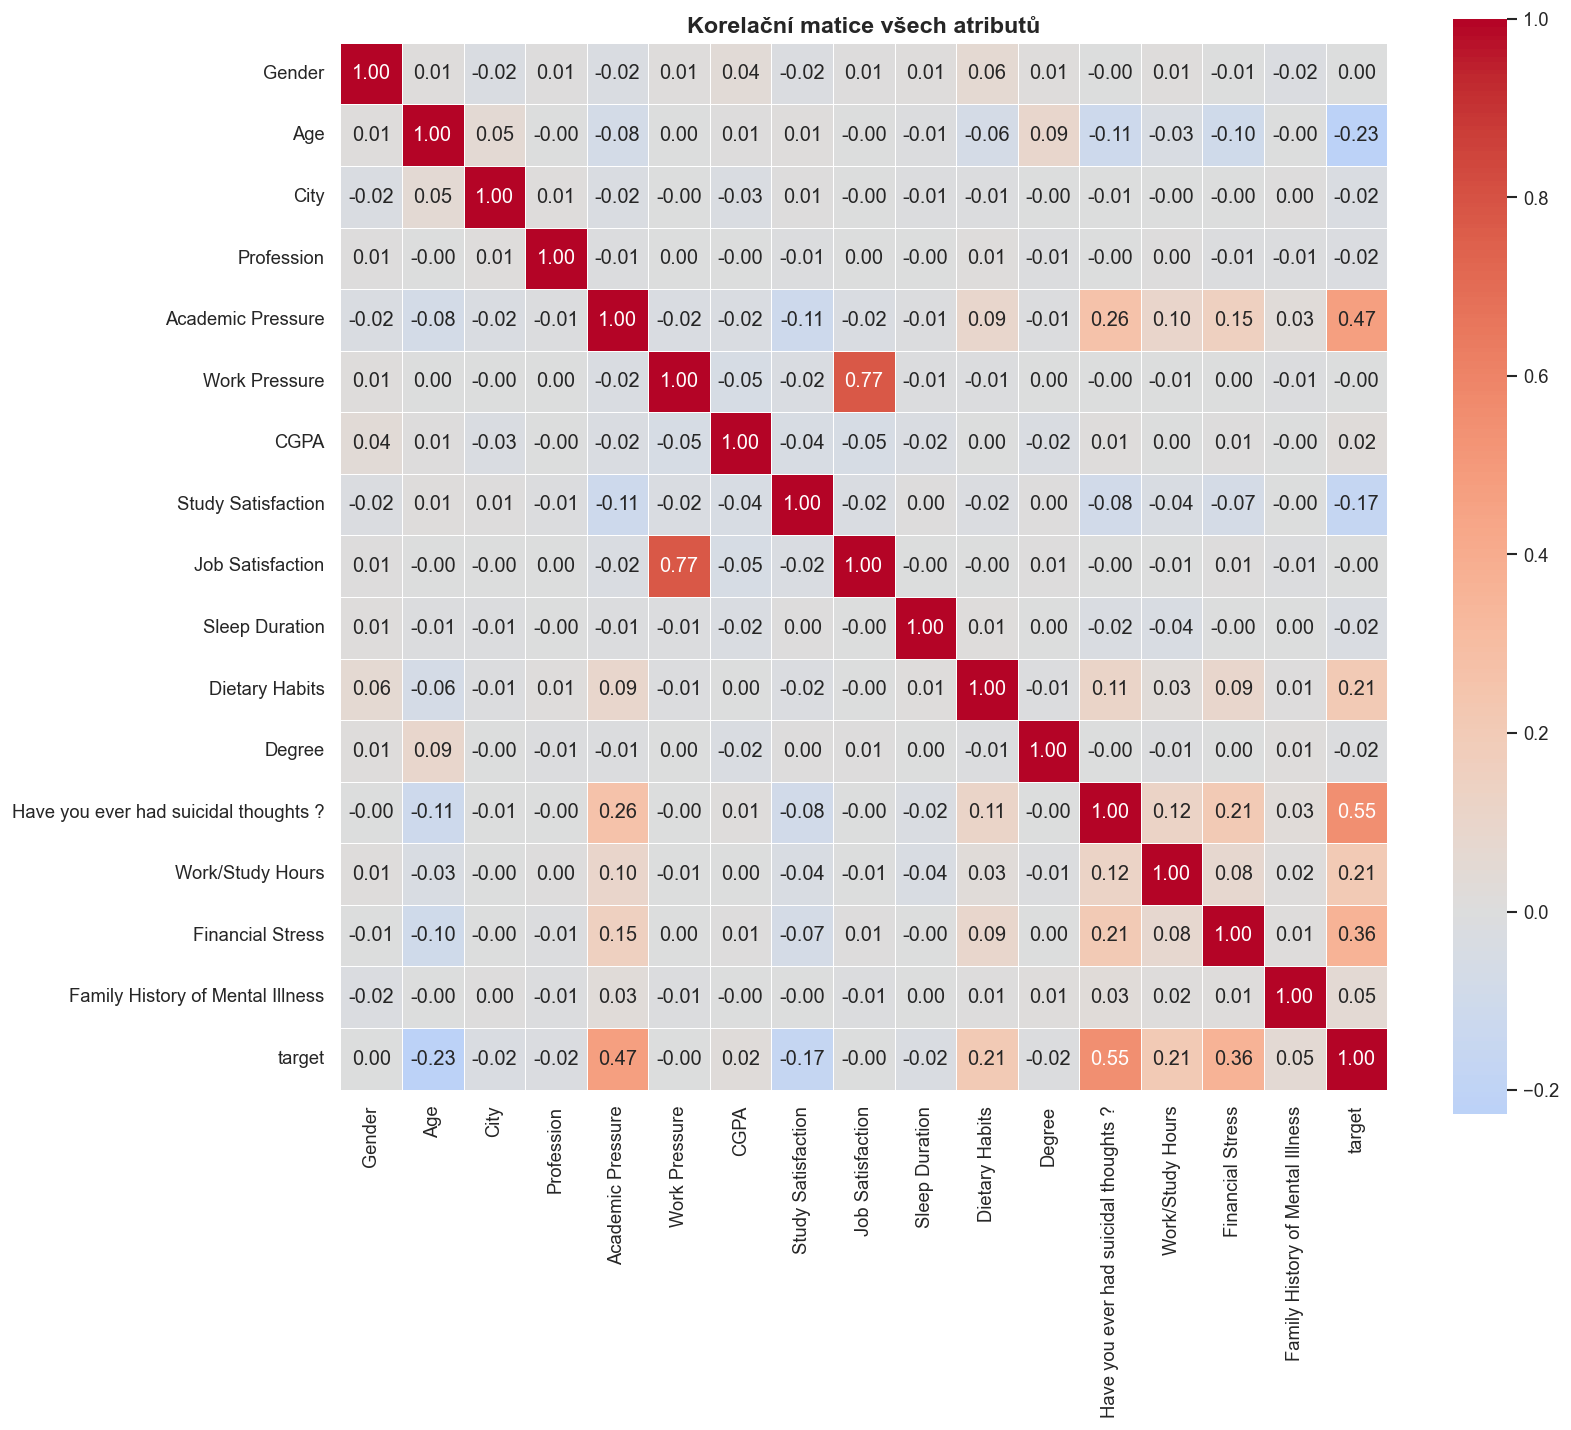

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
df_enc = df.copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))
df_enc['target'] = df_enc['target'].astype(int)

# Square correlation matrix
corr_matrix = df_enc.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Korelační matice všech atributů', fontsize=14)
plt.tight_layout()
plt.savefig('korelacni_matice.png', dpi=150, bbox_inches='tight')
plt.show()


sns.set_theme(style='whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'


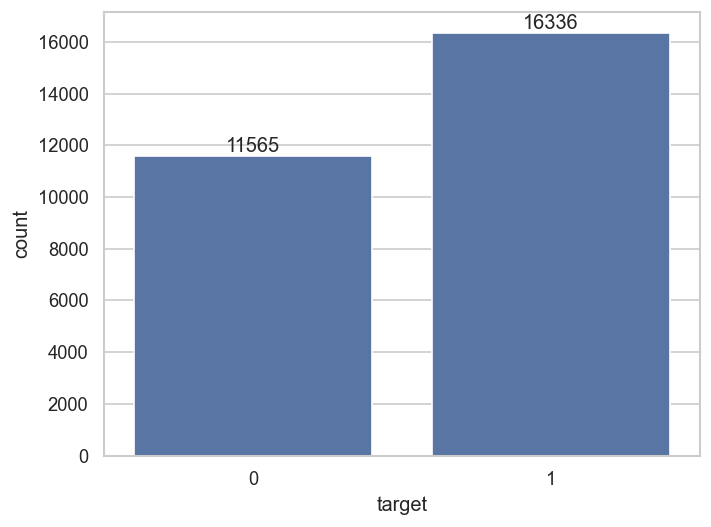

target
1    16336
0    11565
Name: count, dtype: int64


In [54]:
ax = sns.countplot(x='target', data=df)
ax.bar_label(ax.containers[0])
plt.show()
print(df['target'].value_counts())


### Rozlození cílové promenné

Dataset je **nevyvázený** - studentu bez deprese je podstatne více nez tech s diagnózou. To je realistické (deprese není vetšinový jev), ale pro modelování to znamená, ze musíme být opatrní. Model, který by vždy predpovídal "bez deprese", by mel vysokou presnost, ale byl by k nicemu. Proto pri trénování pouzíváme `class_weight="balanced"` a jako hlavní metriku sledujeme recall, nikoliv accuracy.

<Axes: xlabel='Academic Pressure', ylabel='count'>

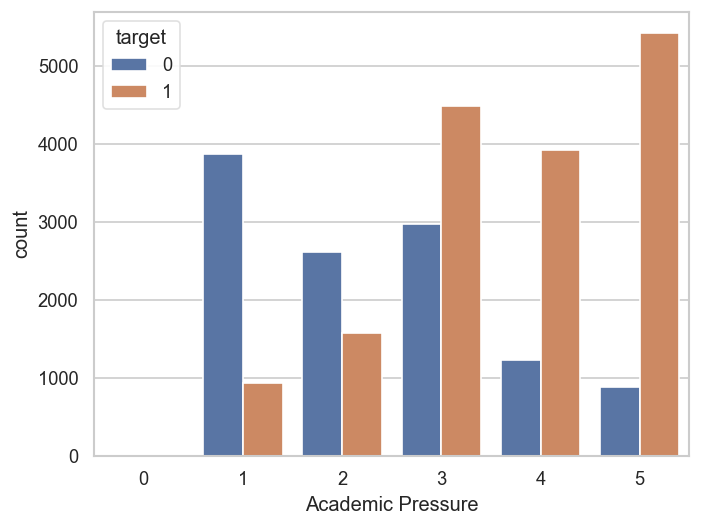

In [55]:
sns.countplot(x='Academic Pressure', hue='target', data=df)


### Academic Pressure a deprese

Graf potvrzuje, co jsme intuitivne cekali: cím vyšší akademický tlak, tím více depresivních studentu. Studenti s tlakem 5 (maximum) mají výrazne vyšší podíl deprese nez ti s tlakem 1 nebo 2. Tento príznak bude pravdepodobne jeden z nejduležitejších v modelu - a zároven jde o príznak, který lze aktivne ovlivnit. Proto jsme ho vybrali jako atribut zájmu.

<Axes: xlabel='Financial Stress', ylabel='Density'>

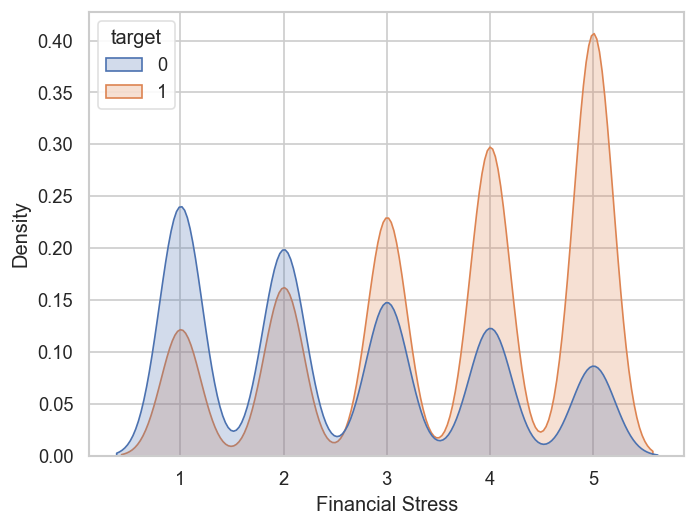

In [56]:
sns.kdeplot(data=df, x='Financial Stress', hue='target', fill=True)


### Financní stres a deprese

KDE graf ukazuje, ze depresivní studenti mají rozdelení financního stresu posunuté doprava - tedy vyšší stres. Oba vrcholy se ale prekrývají, takze financní stres sám o sobe nestací k jednoznacné predikci. V kombinaci s dalšími príznaky ale bude hrát duležitou roli.

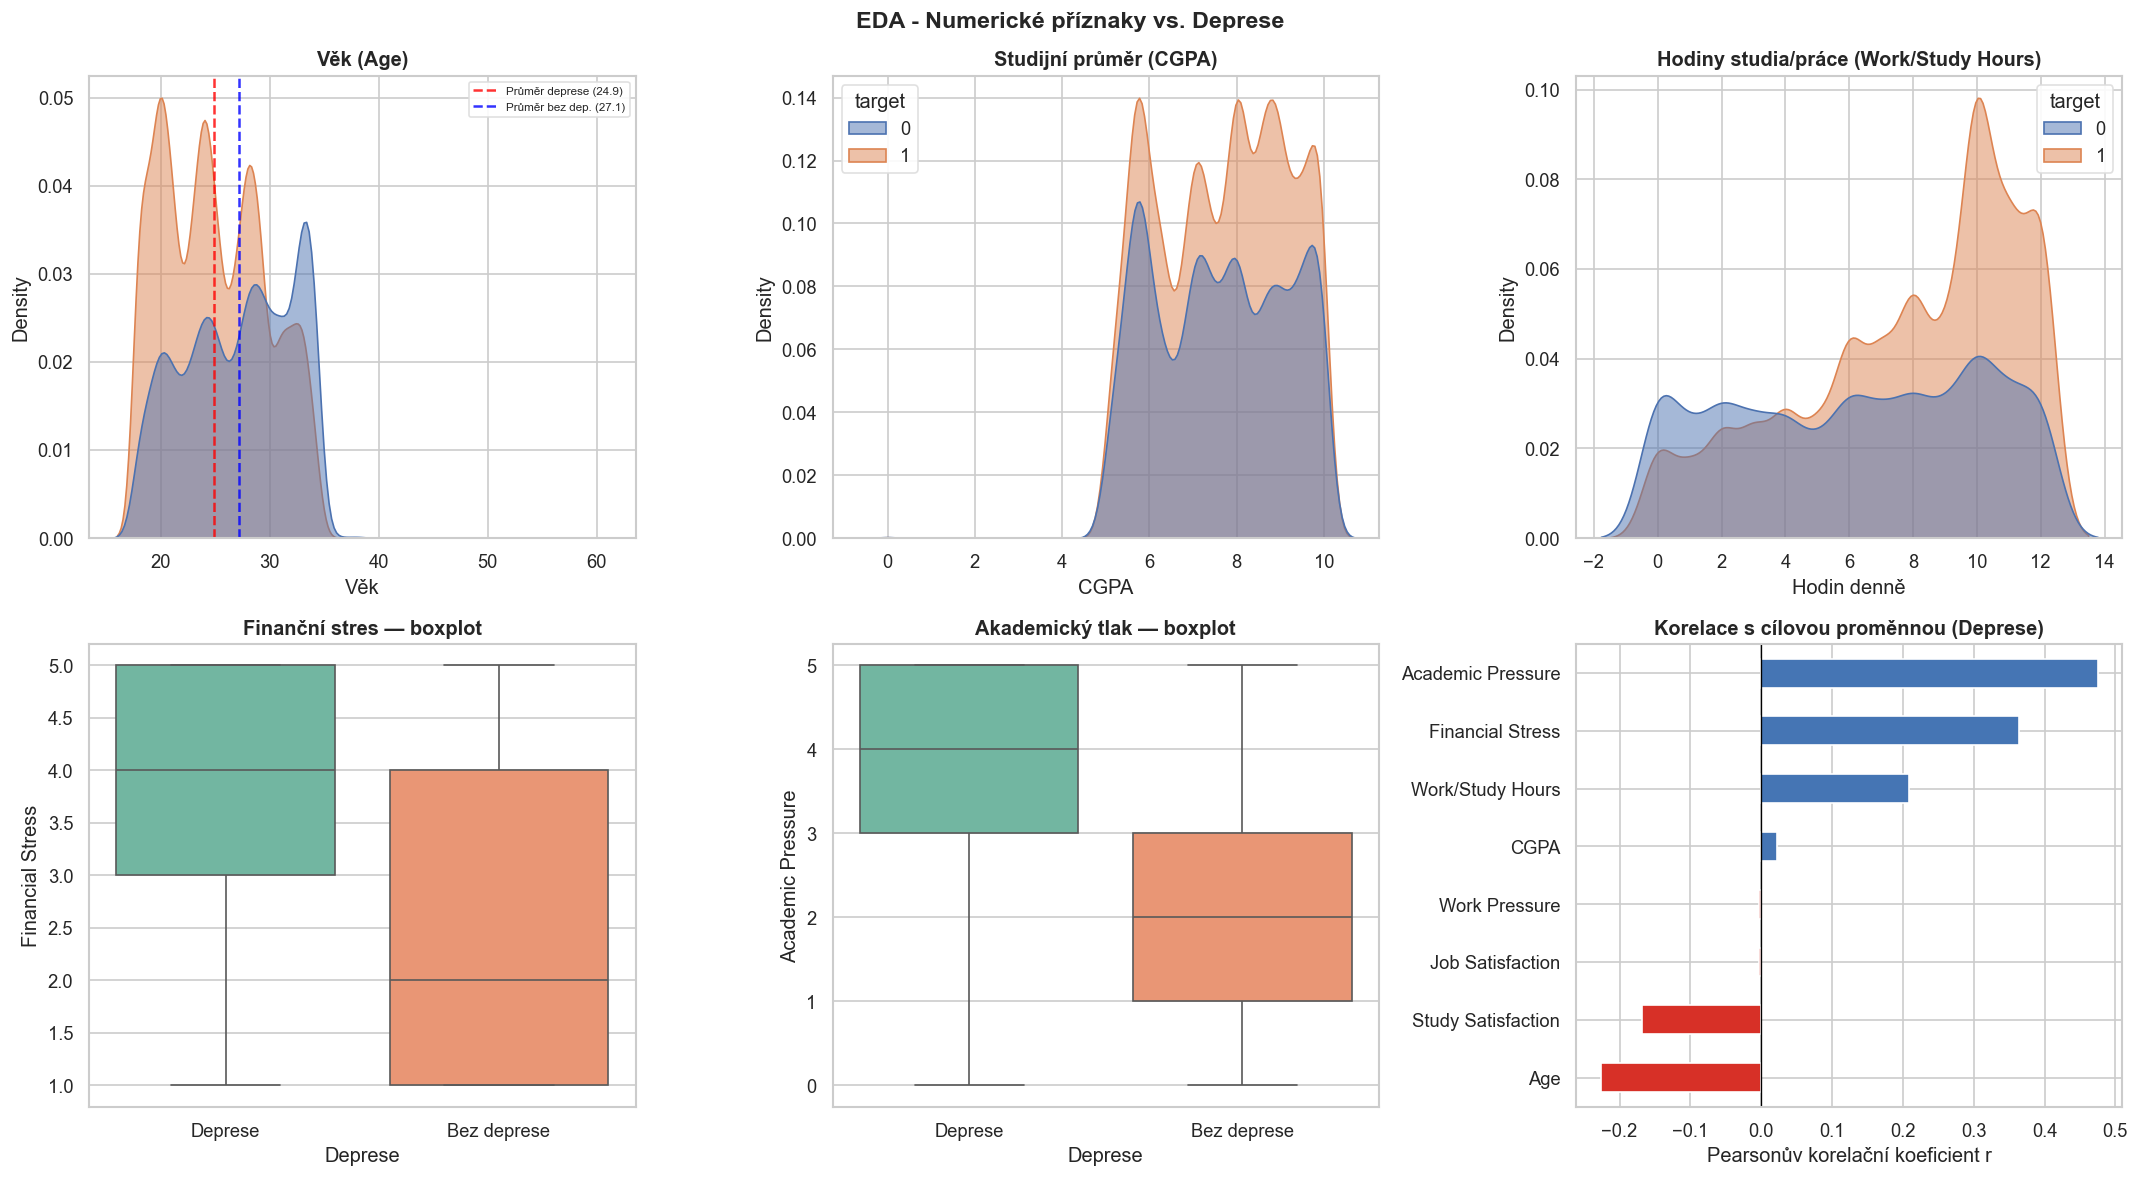

=== Průměrné hodnoty podle třídy ===
                   Bez deprese (0)  Deprese (1)
Age                          27.14        24.89
CGPA                          7.62         7.68
Academic Pressure             2.36         3.69
Financial Stress              2.52         3.58
Work/Study Hours              6.24         7.81

=== Korelace s depresí (sestupně dle abs. hodnoty) ===
Academic Pressure     0.475
Financial Stress      0.364
Age                   0.226
Work/Study Hours      0.209
Study Satisfaction    0.168
CGPA                  0.022
Job Satisfaction      0.003
Work Pressure         0.003


C:\Users\Lakip\AppData\Local\Temp\ipykernel_48788\3423464190.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('target')[num_cols_eda].mean().round(2)


In [57]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.kdeplot(data=df, x='Age', hue='target', fill=True, alpha=0.5, ax=axes[0,0])
age_dep  = df[df['target'].astype(int)==1]['Age'].mean()
age_ndep = df[df['target'].astype(int)==0]['Age'].mean()
axes[0,0].axvline(age_dep,  color='red',  linestyle='--', alpha=0.8, label=f'Průměr deprese ({age_dep:.1f})')
axes[0,0].axvline(age_ndep, color='blue', linestyle='--', alpha=0.8, label=f'Průměr bez dep. ({age_ndep:.1f})')
axes[0,0].set_title('Věk (Age)')
axes[0,0].set_xlabel('Věk')
axes[0,0].legend(fontsize=7)

sns.kdeplot(data=df, x='CGPA', hue='target', fill=True, alpha=0.5, ax=axes[0,1])
axes[0,1].set_title('Studijní průměr (CGPA)')
axes[0,1].set_xlabel('CGPA')

sns.kdeplot(data=df, x='Work/Study Hours', hue='target', fill=True, alpha=0.5, ax=axes[0,2])
axes[0,2].set_title('Hodiny studia/práce (Work/Study Hours)')
axes[0,2].set_xlabel('Hodin denně')

df_box = df.copy()
df_box['Deprese'] = df_box['target'].astype(int).map({0: 'Bez deprese', 1: 'Deprese'})
sns.boxplot(data=df_box, x='Deprese', y='Financial Stress', hue='Deprese',
            ax=axes[1,0], palette='Set2', legend=False)
axes[1,0].set_title('Finanční stres — boxplot')

sns.boxplot(data=df_box, x='Deprese', y='Academic Pressure', hue='Deprese',
            ax=axes[1,1], palette='Set2', legend=False)
axes[1,1].set_title('Akademický tlak — boxplot')

df_corr_num = df.copy()
df_corr_num['target_num'] = df_corr_num['target'].astype(int)
corr_vals = (df_corr_num.select_dtypes(include='number')
             .corr()['target_num']
             .drop('target_num')
             .sort_values())
colors = ['#d73027' if v < 0 else '#4575b4' for v in corr_vals]
corr_vals.plot(kind='barh', ax=axes[1,2], color=colors)
axes[1,2].axvline(0, color='black', linewidth=0.8)
axes[1,2].set_title('Korelace s cílovou proměnnou (Deprese)')
axes[1,2].set_xlabel('Pearsonův korelační koeficient r')

plt.suptitle('EDA - Numerické příznaky vs. Deprese', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_numeric.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Průměrné hodnoty podle třídy ===")
num_cols_eda = ['Age', 'CGPA', 'Academic Pressure', 'Financial Stress', 'Work/Study Hours']
group_stats = df.groupby('target')[num_cols_eda].mean().round(2)
group_stats.index = ['Bez deprese (0)', 'Deprese (1)']
print(group_stats.T.to_string())
print("\n=== Korelace s depresí (sestupně dle abs. hodnoty) ===")
print(corr_vals.abs().sort_values(ascending=False).round(3).to_string())


### Co jsme zjistili z analýzy numerických príznaků

Z grafů KDE, boxplotu a korelacní matice plyne nekolik konkrétních záveru:

- **Academic Pressure a Financial Stress** jsou jasne nejsilnejší numerické prediktory deprese. Boxploty ukazují konzistentní rozdíl mezi obema skupinami studentu.
- **Vek a CGPA** mají korelaci s depresí témer nulovou - ani starší vek ani horší studijní výsledky nejsou samy o sobe rizikovým faktorem.
- **Work/Study Hours** vykazuje mírnou pozitivní korelaci - extrémy nad 10 hodin denne jsou rizikovejší.
- Tato zjištení potvrzují, ze zamerení na Academic Pressure jako atribut zájmu dává smysl.

### Kategorické príznaky a deprese

Podíváme se na kategorické promenné. Pro kazdou kategorii spocítáme procento studentu s depresí a porovnáme ho s celkovým průmerem (cervená cara). Kategorie nad touto hranicí jsou rizikové skupiny.

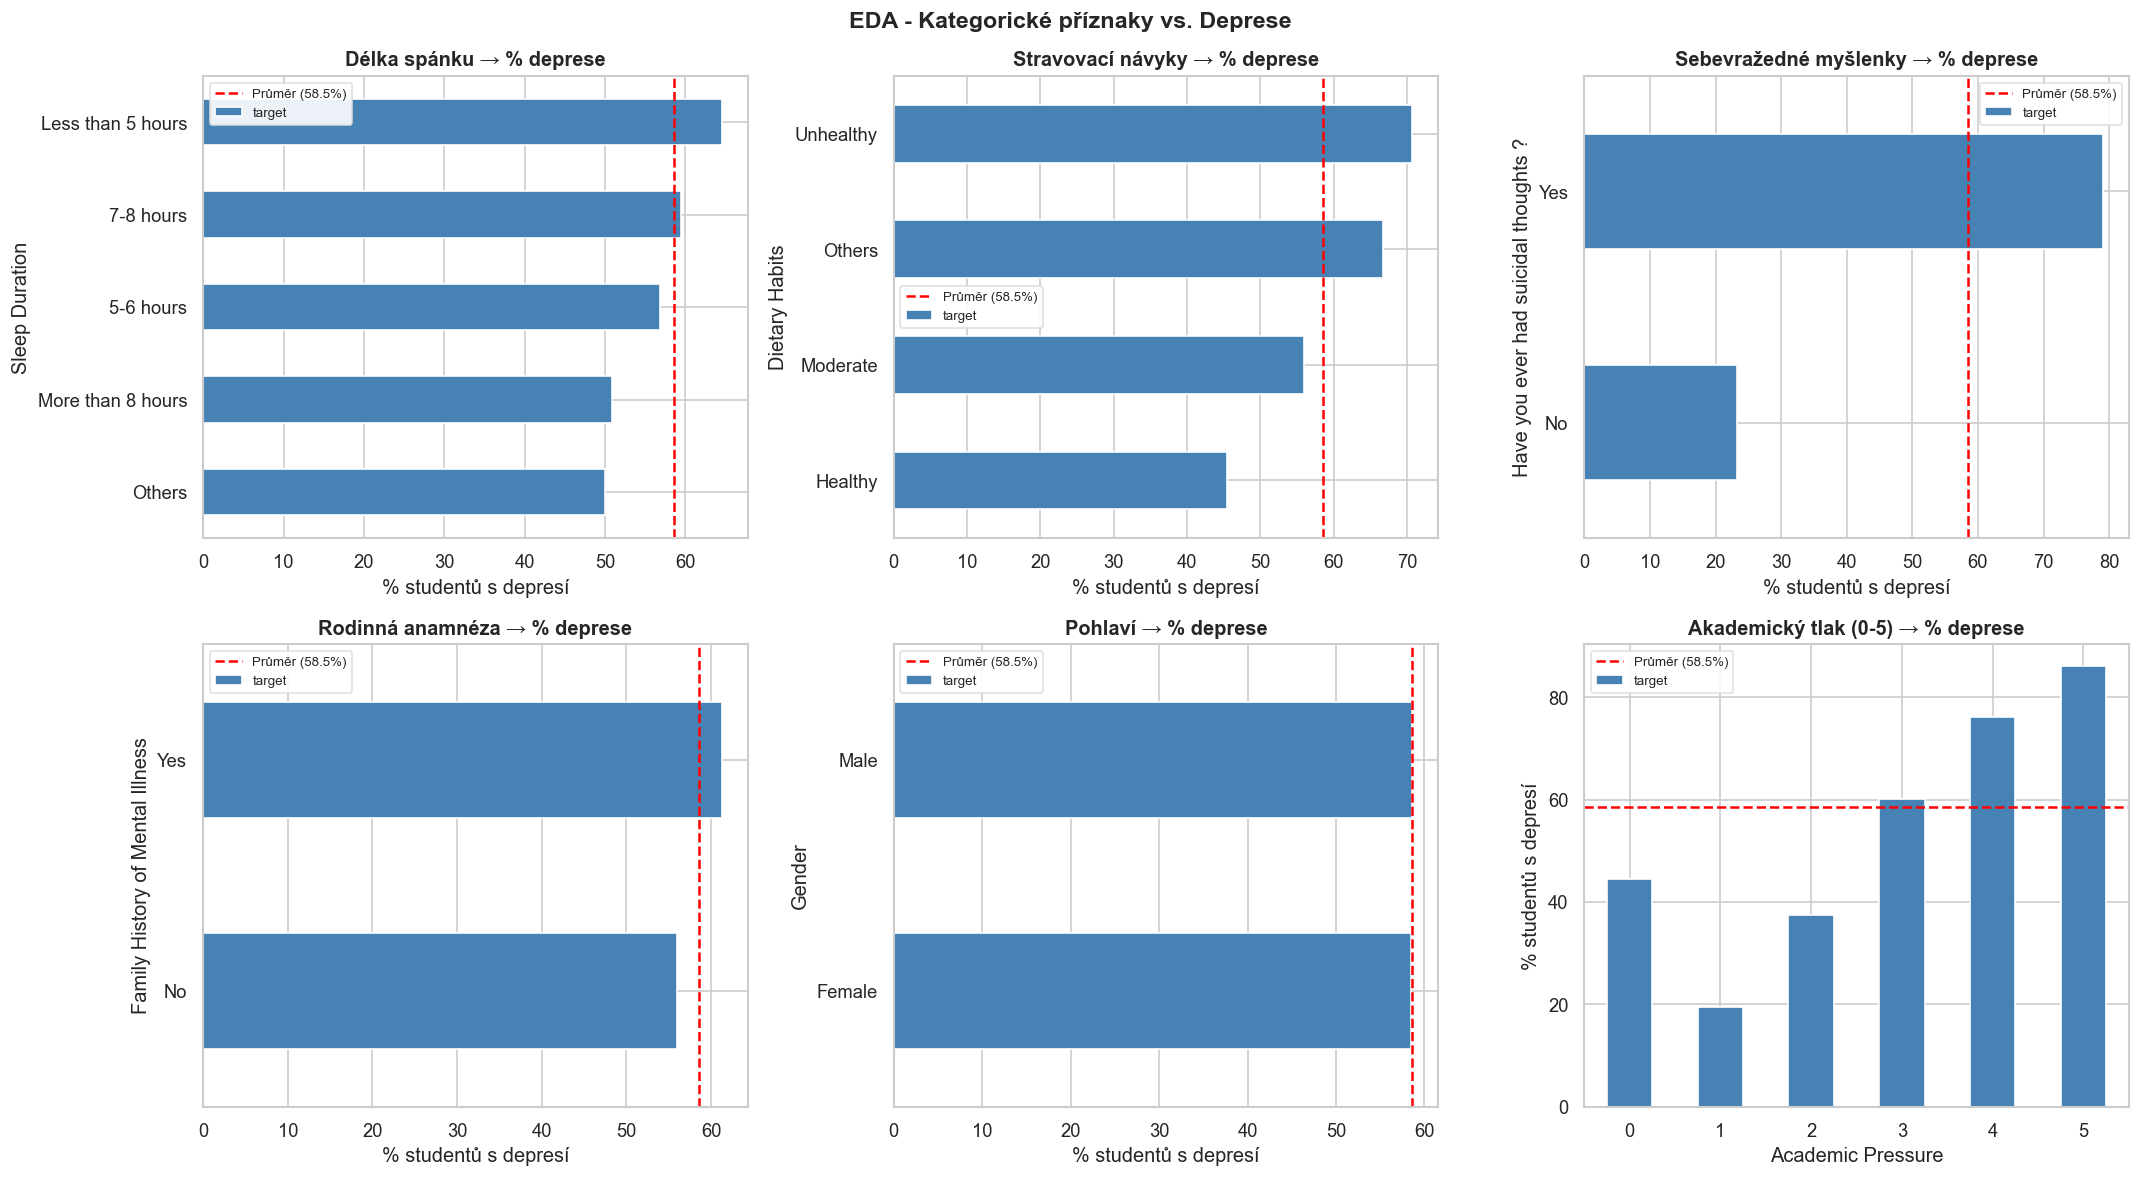

=== Přesné hodnoty % deprese ===

Sleep Duration:
Sleep Duration
Others               50.0
More than 8 hours    50.9
5-6 hours            56.9
7-8 hours            59.5
Less than 5 hours    64.5

Dietary Habits:
Dietary Habits
Healthy      45.4
Moderate     56.0
Others       66.7
Unhealthy    70.7

Have you ever had suicidal thoughts ?:
Have you ever had suicidal thoughts ?
No     23.2
Yes    79.0

Family History of Mental Illness:
Family History of Mental Illness
No     56.0
Yes    61.3

Gender:
Gender
Female    58.5
Male      58.6


In [58]:
avg_depression = df['target'].astype(int).mean() * 100

def depression_pct(col):
    return df.groupby(col)['target'].apply(lambda x: x.astype(int).mean() * 100).sort_values()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
s = depression_pct('Sleep Duration')
s.plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].axvline(avg_depression, color='red', linestyle='--', label=f'Průměr ({avg_depression:.1f}%)')
axes[0,0].set_title('Délka spánku → % deprese')
axes[0,0].set_xlabel('% studentů s depresí')
axes[0,0].legend(fontsize=8)

d = depression_pct('Dietary Habits')
d.plot(kind='barh', ax=axes[0,1], color='steelblue')
axes[0,1].axvline(avg_depression, color='red', linestyle='--', label=f'Průměr ({avg_depression:.1f}%)')
axes[0,1].set_title('Stravovací návyky → % deprese')
axes[0,1].set_xlabel('% studentů s depresí')
axes[0,1].legend(fontsize=8)

su = depression_pct('Have you ever had suicidal thoughts ?')
su.plot(kind='barh', ax=axes[0,2], color='steelblue')
axes[0,2].axvline(avg_depression, color='red', linestyle='--', label=f'Průměr ({avg_depression:.1f}%)')
axes[0,2].set_title('Sebevražedné myšlenky → % deprese')
axes[0,2].set_xlabel('% studentů s depresí')
axes[0,2].legend(fontsize=8)

fh = depression_pct('Family History of Mental Illness')
fh.plot(kind='barh', ax=axes[1,0], color='steelblue')
axes[1,0].axvline(avg_depression, color='red', linestyle='--', label=f'Průměr ({avg_depression:.1f}%)')
axes[1,0].set_title('Rodinná anamnéza → % deprese')
axes[1,0].set_xlabel('% studentů s depresí')
axes[1,0].legend(fontsize=8)

g = depression_pct('Gender')
g.plot(kind='barh', ax=axes[1,1], color='steelblue')
axes[1,1].axvline(avg_depression, color='red', linestyle='--', label=f'Průměr ({avg_depression:.1f}%)')
axes[1,1].set_title('Pohlaví → % deprese')
axes[1,1].set_xlabel('% studentů s depresí')
axes[1,1].legend(fontsize=8)

ap = df.groupby('Academic Pressure')['target'].apply(lambda x: x.astype(int).mean() * 100)
ap.plot(kind='bar', ax=axes[1,2], color='steelblue')
axes[1,2].axhline(avg_depression, color='red', linestyle='--', label=f'Průměr ({avg_depression:.1f}%)')
axes[1,2].set_title('Akademický tlak (0-5) → % deprese')
axes[1,2].set_xlabel('Academic Pressure')
axes[1,2].set_ylabel('% studentů s depresí')
axes[1,2].tick_params(axis='x', rotation=0)
axes[1,2].legend(fontsize=8)

plt.suptitle('EDA - Kategorické příznaky vs. Deprese', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Přesné hodnoty % deprese ===")
for col in ['Sleep Duration', 'Dietary Habits',
            'Have you ever had suicidal thoughts ?',
            'Family History of Mental Illness', 'Gender']:
    print(f"\n{col}:")
    print(depression_pct(col).round(1).to_string())


### Co nám kategorické príznaky ríkají

Z grafů jsou vidět jasné vzory:

- **Sebevražedné myšlenky** jsou zdaleka nejsilnejším prediktorem - studenti, kteří odpovedelí "Yes", mají dramaticky vyšší výskyt deprese. Tohle bude pravdepodobne nejduležitejší príznak v celém modelu.
- **Délka spánku** hraje roli - studenti spící méne nez 5 hodin jsou nad průmerem, ti se spánkem 7-8 hodin pod ním. Dostatecný spánek funguje jako ochranný faktor.
- **Stravovací návyky** potvrzují, ze "Unhealthy" skupina má vyšší výskyt deprese - životní styl jde ruku v ruce s dusevním zdravím.
- **Rodinná anamnéza** má vliv, ale není determinující - biologická predispozice riziko zvyšuje, ale neznamená automaticky depresi.
- **Pohlaví** nevykazuje rozdíl.

### Shrnutí EDA - co jsme se naucili

Na základe průzkumu dat jsme si formulovali hypotézy, které budeme overovat modely:

| Hypotéza | Príznak | Co ocekáváme |
|---|---|---|
| H1 | Academic Pressure | Tlak >= 4 výrazne zvyšuje riziko deprese |
| H2 | Financial Stress | Vyšší financní stres koreluje s depresí |
| H3 | Suicidal thoughts = Yes | Nejsilnejší kategorický prediktor |
| H4 | Sleep Duration | Krátký spánek (< 5 h) koreluje s depresí |
| H5 | Dietary Habits = Unhealthy | Špatné stravování koreluje s vyšší prevalencí |
| H6 | Family History = Yes | Rodinná anamnéza zvyšuje riziko |
| H7 | CGPA | Slabý nebo zádný efekt |
| H8 | Work/Study Hours | Extrémy nad 10 h/den jsou rizikovejší |

Deprese je multifaktoriální jev - zádný jeden príznak nestací k predikci. To potvrzuje, ze má smysl pouzít ensemble metody jako Random Forest, které zachytí slozité interakce mezi príznaky.

## 3. Predzpracování dat

S daty dobre rozumíme - víme, co v nich je, jak vypadají a co zhruba ovlivnuje depresi. Teď je treba je pripravit tak, aby je modely mohly zpracovat. Predzpracování jsme rozdlili na dve cásti: pro klasifikaci a pro shlukování.

### Predzpracování pro klasifikaci

Cílovým atributem je `Depression` - binární promenná (0 = deprese není prítomna, 1 = deprese je prítomna). V datech je atribut jiz v binárním formátu, takze zádná transformace není treba.

### Rozdelení na trénovací a testovací mnozinu

Data jsme rozdélili v pomeru 80/20 - 80 % dat jde do trénovací mnoziny, 20 % tvorí testovací. Pouzili jsme stratifikované delení, aby byl v obou castech zachován stejný podíl depresivních a nedepresivních studentu. Pro reprodukovatelnost je nastaven pevný `random_state=42`. Klícové pravidlo: testovací mnozina se pri trénování ani ladení parametru vůbec nepouzívá - slouží výhradne pro finální hodnocení.

In [90]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=["target"])
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Velikost trénovací množiny: {len(X_train)}")
print(f"Velikost testovací množiny: {len(X_test)}")

Velikost trénovací množiny: 22320
Velikost testovací množiny: 5581


### Ošetrení chybejících hodnot

Overíme, zda data obsahují prázdné hodnoty (NaN). Ukázalo se, ze chybející hodnoty má pouze príznak `Financial Stress`. Chybející hodnoty jsme nahradili mediánem trénovací mnoziny - tento postup je bezpecný, protože nepouzívá informace z testovací sady.

In [91]:
df.isnull().sum()

Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
target                                   0
Stress_Index                             0
dtype: int64

In [61]:
median_fs = X_train["Financial Stress"].median()
X_train["Financial Stress"] = X_train["Financial Stress"].fillna(median_fs)
X_test["Financial Stress"]  = X_test["Financial Stress"].fillna(median_fs)

X_test.isnull().sum()

Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
dtype: int64

### Výber príznaků (feature selection)

Cílem je zbavit se príznaků, které neprinášejí uzitecnou informaci nebo by zbytecne komplikovaly model a zvyšovaly riziko pretucení. Postupovali jsme ve trech krocích.

**Krok 1 - odstranení výsokokardinálních kategorií**

Atributy `City` a `Degree` mají príliš mnoho různých hodnot (52 mest, 28 studijních programu). Po one-hot kódování by kazdy z nich pridal desítky nových sloupcu, z nichz vetsina by byla témer prázdná. To zbytecne zvyšuje dimenzi prostoru a riziko pretucení. Oba atributy proto odstraníme.

In [92]:

cols = ["City", "Degree"]  
rare_threshold = 0.03         
top_n = 15

n = len(df)
rows = []

for c in cols:
    if c not in df.columns:
        continue
    
    vc = df[c].astype("object").value_counts(dropna=False)
    nunique = df[c].nunique(dropna=False)
    top1_share = (vc.iloc[0] / n) if len(vc) else 0.0
    rare_count = int((vc / n < rare_threshold).sum())

    rows.append({
        "column": c,
        "rows": n,
        "nunique": int(nunique),
        "top1_share": float(top1_share),
        f"rare_categories(<{rare_threshold:.0%})": rare_count,
        "top_categories": vc.head(top_n).to_dict()
    })

report = pd.DataFrame(rows)
print(report[["column", "rows", "nunique", "top1_share", f"rare_categories(<{rare_threshold:.0%})"]])
print("\nTop categories preview:")
for _, r in report.iterrows():
    print("\n", r["column"], r["top_categories"])


   column   rows  nunique  top1_share  rare_categories(<3%)
0    City  27901       52    0.056270                    35
1  Degree  27901       28    0.217913                    17

Top categories preview:

 City {'Kalyan': 1570, 'Srinagar': 1372, 'Hyderabad': 1340, 'Vasai-Virar': 1290, 'Lucknow': 1155, 'Thane': 1139, 'Ludhiana': 1111, 'Agra': 1094, 'Surat': 1078, 'Kolkata': 1066, 'Jaipur': 1036, 'Patna': 1007, 'Visakhapatnam': 969, 'Pune': 968, 'Ahmedabad': 951}

 Degree {'Class 12': 6080, 'B.Ed': 1867, 'B.Com': 1506, 'B.Arch': 1478, 'BCA': 1433, 'MSc': 1190, 'B.Tech': 1152, 'MCA': 1044, 'M.Tech': 1022, 'BHM': 925, 'BSc': 888, 'M.Ed': 821, 'B.Pharm': 810, 'M.Com': 734, 'BBA': 696}


**Krok 2 - odstranení témer konstantních atributu**

Atribut `Profession` obsahuje z drtivé vetsiny jen jednu hodnotu ("Student"). Takový príznak modelu nic neríká - témer pro kazdého studenta by mel stejnou hodnotu. Odstraníme ho.

In [93]:
target = "target"  # název cílového sloupce


cat_threshold = 0.95 

candidates = []
n = len(df)

for c in df.columns:
    if c == target:
        continue
    if not pd.api.types.is_numeric_dtype(df[c]):  
        vc = df[c].astype("object").value_counts(dropna=False)
        top_share = (vc.iloc[0] / n) if len(vc) else 0.0
        if top_share >= cat_threshold:
            candidates.append((c, float(top_share), vc.index[0]))

candidates = sorted(candidates, key=lambda x: x[1], reverse=True)
print("Near-constant categorical (top1_share >= 0.95):")
for c, share, top_val in candidates[:50]:
    print(f"{c:35s} top1_share={share:.3f}   most_common={top_val!r}")


Near-constant categorical (top1_share >= 0.95):
Profession                          top1_share=0.999   most_common='Student'


### Analýza multikolinearity pomocí VIF

#### Co je VIF?

VIF (Variance Inflation Factor) nám ríká, nakolik je jeden príznak "vysvetlitelný" ostatními príznaky v datasetu. Zjednodušene: zkusíme predpovedet hodnotu jednoho atributu pomocí všech ostatních. Pokud to jde dobre (vysoké R2), pak tento atribut nese pouze informaci, která je uz obsazena jinde - a je kandidátem na odstranení.

Pravidlo, které jsme pouzili: VIF > 10 signalizuje problematickou multikolinearitu.

In [94]:
target = "target"  # název cílového sloupce


from sklearn.linear_model import LinearRegression

X_num = df.select_dtypes(include=["number"]).copy()
if target in X_num.columns:
    X_num = X_num.drop(columns=[target])


X_num = X_num.fillna(X_num.median(numeric_only=True))

lr = LinearRegression()
vifs = []

cols = X_num.columns.tolist()

for col in cols:
    y_col = X_num[col].values
    X_others = X_num.drop(columns=[col]).values

    if X_others.shape[1] == 0:
        vifs.append((col, np.nan))
        continue

    lr.fit(X_others, y_col)
    r2 = lr.score(X_others, y_col)
    vif = np.inf if r2 >= 0.999999 else 1.0 / (1.0 - r2)
    vifs.append((col, float(vif)))

vif_df = pd.DataFrame(vifs, columns=["feature", "VIF"]).sort_values("VIF", ascending=False)
print(vif_df.head(30))

              feature       VIF
1   Academic Pressure       inf
7    Financial Stress       inf
8        Stress_Index       inf
5    Job Satisfaction  2.464634
2       Work Pressure  2.463308
4  Study Satisfaction  1.018478
6    Work/Study Hours  1.014163
0                 Age  1.013534
3                CGPA  1.006111


In [95]:
drop_cols = ["City", "Profession", "Job Satisfaction", "Degree"]
df_reduced = df.drop(columns=drop_cols, errors="ignore")

print("Bylo:", df.shape)
print("Ted':", df_reduced.shape)
print("Smazano:", [c for c in drop_cols if c in df.columns])

Bylo: (27901, 18)
Ted': (27901, 14)
Smazano: ['City', 'Profession', 'Job Satisfaction', 'Degree']


Výkon baseline modelu a modelu po feature selection je prakticky stejný (ROC-AUC 0.9212), takze zjednodušení datasetu výkon nezhoršilo. Pracujeme tedy s redukovanou verzí - je jednodušší a trénování bude rychlejší.

In [96]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

cv_check = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def encode_for_cv(dataframe, target_col):
    d = dataframe.copy()
    for col in d.select_dtypes(include="object").columns:
        d[col] = LabelEncoder().fit_transform(d[col].astype(str))
    X_ = d.drop(columns=[target_col])
    y_ = d[target_col].astype(int)
    return X_, y_

X_base_cv, y_base_cv = encode_for_cv(df, "target")
X_red_cv,  y_red_cv  = encode_for_cv(df_reduced, "target")

pipe_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   LogisticRegression(max_iter=2000, solver="liblinear",
                                   class_weight="balanced", random_state=42)),
])

s_base = cross_val_score(pipe_lr, X_base_cv, y_base_cv, cv=cv_check, scoring="roc_auc")
s_red  = cross_val_score(pipe_lr, X_red_cv,  y_red_cv,  cv=cv_check, scoring="roc_auc")

print(f"Baseline (všechny příznaky)       ROC-AUC: {s_base.mean():.4f} ± {s_base.std():.4f}")
print(f"Redukovaný (po feature selection) ROC-AUC: {s_red.mean():.4f} ± {s_red.std():.4f}")
print("\nZávěr: Výkon je prakticky totožný → feature selection neSnížila prediktivní sílu,")
print("        ale zjednodušila dataset a snížila výpočetní náročnost.")

Baseline (všechny příznaky)       ROC-AUC: 0.9198 ± 0.0016
Redukovaný (po feature selection) ROC-AUC: 0.9199 ± 0.0015

Závěr: Výkon je prakticky totožný → feature selection neSnížila prediktivní sílu,
        ale zjednodušila dataset a snížila výpočetní náročnost.


### Odvození nového príznaku - Stress Index

Z existujících príznaků jsme odvodili nový kombinovaný ukazatel `Stress_Index`, který průmeruje akademický tlak a financní stres do jednoho skóre (škála 0-5). Myšlenka je jednoduchá: oba tyto faktory spolu úzce souvisí a jejich kombinace muze být lepším prediktorem nez kazdy zvlášt. Zároven nám to umozní lépe vizualizovat celkovou zátez studenta.

Ukázka nového příznaku Stress_Index:
   Academic Pressure  Financial Stress  Stress_Index target
0                  5               1.0           3.0      1
1                  2               2.0           2.0      0
2                  3               1.0           2.0      0
3                  3               5.0           4.0      1
4                  4               1.0           2.5      0
5                  2               1.0           1.5      0
6                  3               2.0           2.5      0
7                  2               1.0           1.5      0

Korelace Stress_Index s cílovou proměnnou: 0.551


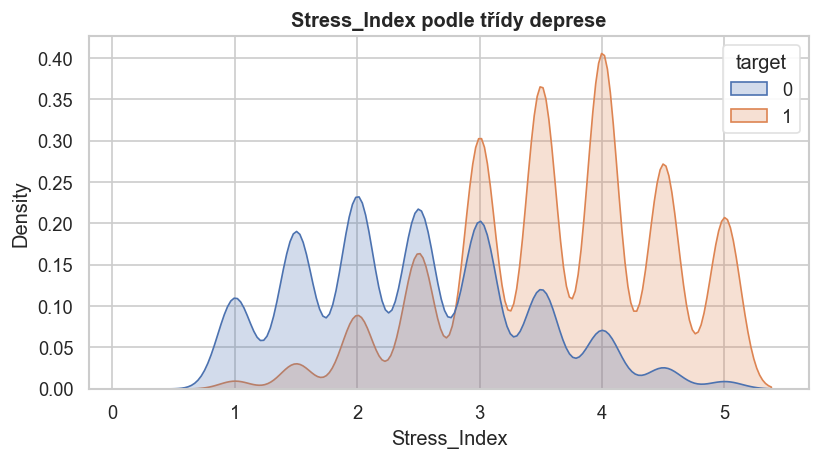

In [97]:
median_fs = df["Financial Stress"].median()
df["Stress_Index"] = (df["Academic Pressure"].astype(float) +
                      df["Financial Stress"].fillna(median_fs)) / 2.0

print("Ukázka nového příznaku Stress_Index:")
print(df[["Academic Pressure", "Financial Stress", "Stress_Index", "target"]].head(8))
print(f"\nKorelace Stress_Index s cílovou proměnnou: "
      f"{df['Stress_Index'].corr(df['target'].astype(int)):.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=df, x="Stress_Index", hue="target", fill=True, ax=ax)
ax.set_title("Stress_Index podle třídy deprese")
ax.set_xlabel("Stress_Index")
plt.tight_layout()
plt.savefig("stress_index.png", dpi=150, bbox_inches="tight")
plt.show()


In [98]:
target = "target"
drop_cols = ["City", "Profession", "Job Satisfaction", "Degree"]  

df = df.copy()
df.columns = df.columns.str.strip()

X = df.drop(columns=[target] + [c for c in drop_cols if c in df.columns])
y = df[target].astype("int8")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_ohe = pd.get_dummies(X_train, drop_first=False, dtype="int8")
X_test_ohe  = pd.get_dummies(X_test,  drop_first=False, dtype="int8")

X_test_ohe = X_test_ohe.reindex(columns=X_train_ohe.columns, fill_value=0)

X_train_ohe.columns = X_train_ohe.columns.str.replace(" ", "")
X_test_ohe.columns  = X_test_ohe.columns.str.replace(" ", "")

print(X_test_ohe.shape, X_test_ohe.shape)
print(X_train_ohe.head())

cols_to_drop = [c for c in X_train_ohe.columns
                if ("Other" in c or "other" in c) and (c.startswith("Dietary") or c.startswith("Sleep"))]

X_train_ohe = X_train_ohe.drop(columns=cols_to_drop)
X_test_ohe  = X_test_ohe.drop(columns=cols_to_drop, errors="ignore")

print("Dropped:", cols_to_drop)


(5581, 23) (5581, 23)
       Age  AcademicPressure  WorkPressure  CGPA  StudySatisfaction  \
1657    18                 4             0  6.02                  1   
24995   25                 3             0  6.37                  2   
27613   30                 3             0  9.24                  2   
13512   34                 3             0  7.37                  5   
27029   25                 3             0  7.47                  4   

       Work/StudyHours  FinancialStress  Stress_Index  Gender_Female  \
1657                 3              5.0           4.5              0   
24995                9              1.0           2.0              0   
27613                5              5.0           4.0              0   
13512               12              3.0           3.0              0   
27029               11              5.0           4.0              0   

       Gender_Male  ...  SleepDuration_Morethan8hours  SleepDuration_Others  \
1657             1  ...                

## 4. Modelování a hyperparameter tuning

S predzpracovanými daty trénujeme pet modelu. Každý model má tzv. **hyperparametry** - nastavení, která se neucí z dat, ale my je volíme pred trénováním. Špatná volba hyperparametru muze vést k pretucení (model se navcí na trénovací data nazpamety a na nových datech selhává) nebo k podtucení (model je príliš jednoduchý a nic nezachytí).

Proto pouzíváme **GridSearchCV** a **RandomizedSearchCV** - automaticky vyzkoušíme mnoho kombinací parametru, každou ohodnotíme 5-násobnou krízkovou validací na trénovacích datech, a vybereme tu nejlepší.

---

### 4.1 Baseline model

`DummyClassifier` priradzuje trídy náhodne podle jejich cetnosti. Slouží jako spodní hranice - každý smysluplný model by ho mel výrazne prekonat. Žádné hyperparametry.

---

### 4.2 Logistická regrese - co ladíme a proc

| Hyperparametr | Co ríká | Proc ho ladíme |
|---|---|---|
| `C` | Sila regularizace - malé C = silná penalizace velkých koeficientu | Príliš velké C = model se preuct; príliš malé = príliš zjednodušený |
| `penalty` | L1 (Lasso) vs L2 (Ridge) | L1 muze nulovat celé príznaky (vestavená selekce), L2 všechny shrne |

---

### 4.3 Rozhodovací strom - co ladíme a proc

| Hyperparametr | Co ríká | Proc ho ladíme |
|---|---|---|
| `max_depth` | Maximální hloubka stromu | Moc hluboký = pretucení; moc mělký = ztráta informace |
| `min_samples_leaf` | Min. vzorku v listu | Vyšší hodnota = jednodušší strom, lépe generalizuje |
| `min_samples_split` | Min. vzorku pro rozdelení uzlu | Vyšší = konzervativnejší vetví |
| `max_features` | Kolik príznaků zvažovat v každém uzlu | sqrt = standard, log2 = konzervativnejší, None = všechny |
| `criterion` | Míra nečistoty (gini vs entropy) | Obvykle dávají podobné výsledky, ale záleží na datech |
| `ccp_alpha` | Post-pruning - oreže vetve, které prináší málo | Cistí strom po trénování, snizuje pretucení |

---

### 4.4 Náhodný les - co ladíme a proc

Protože kombinací je príliš mnoho pro vyčerpávající grid, pouzíváme **RandomizedSearchCV** - náhodne vzorkuje z definovaného prostoru parametru. 60 iterací pokryje prostor lépe nez malý grid.

| Hyperparametr | Co ríká | Proc ho ladíme |
|---|---|---|
| `n_estimators` | Pocet stromu v lese | Více = lepší, ale pomalejší; hledáme optimum |
| `max_depth` | Hloubka každého stromu | Hluboké stromy zachytí více vzoru, ale mohou se pretucit |
| `min_samples_leaf` | Min. vzorku v listu | Kontrola komplexity jednotlivých stromu |
| `min_samples_split` | Min. vzorku pro vetví | Vyšší = konzervativnejší rozhodování |
| `max_features` | Príznaky na vetví | sqrt je standard pro klasifikaci; snizuje korelaci mezi stromy |
| `bootstrap` | Vzorkování s opakováním | True = klasický RF; False = každý strom vidi všechna data |

> Veškeré ladení probíhá výhradne na trénovacích datech. Testovací množina se použije až na konci.
---

### 4.5 XGBoost + Optuna - co ladíme a proc

**XGBoost** (eXtreme Gradient Boosting) funguje jinak nez náhodný les. Místo paralelního budování nezávislých stromu buduje stromy **postupne** - každý nový strom opravuje chyby toho predchozího. Tento prístup se nazývá **gradient boosting** a na strukturovaných tabulkových datech casto prekonává i Random Forest.

Protože má XGBoost hodne hyperparametru, pouzíváme **Optuna** - framework pro Bayesovskou optimalizaci. Na rozdíl od RandomizedSearch, který vzorkuje parametry náhodne, si Optuna pamatuje výsledky predchozích zkoušek a soustredí hledání na oblasti prostoru, kde jsou výsledky nejlepší. 50 iterací Optuny je efektivitou srovnatelných se 300+ náhodnými zkouškami.

| Hyperparametr | Co ríká | Proc ho ladíme |
|---|---|---|
| `n_estimators` | Pocet boostovacích iterací (stromu) | Více = lepší, ale pomalejší a riziko pretucení |
| `max_depth` | Hloubka každého stromu | XGBoost používá mélcí stromy nez RF - obvykle 3-8 |
| `learning_rate` | Krok ucení - jak moc každý strom prispívá | Malé = opatrnejší ucení, lépe generalizuje |
| `subsample` | Podíl dat pro trénování každého stromu | Náhodnost snizuje pretucení |
| `colsample_bytree` | Podíl príznaků pro každý strom | Podobná role jako `max_features` u RF |
| `min_child_weight` | Min. suma vah vzorku v listu | Vyšší = konzervativnejší strom |
| `gamma` | Min. zisk pro rozdelení uzlu | Vyšší = "lenivejší" strom, cistší struktura |
| `reg_alpha` | L1 regularizace (Lasso) | Muze vynulovat nedulezité príznaky |
| `reg_lambda` | L2 regularizace (Ridge) | Brzdí velké váhy, standard pro XGBoost |
| `scale_pos_weight` | Váha pozitivní trídy | Automaticky kompenzuje nevyvázenost tríd |

> **Proc Optuna místo GridSearch?** Prostor parametru XGBoost je príliš velký pro vyčerpávající prohledávání. Optuna používá **TPE sampler** (Tree-structured Parzen Estimator) - po každé zkoušce aktualizuje model toho, kde v prostoru jsou slibné hodnoty, a príští zkušku umístí tam. Výsledkem je výrazne efektivnejší hledání nez náhodné vzorkování.

In [99]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

# --- Baseline model ---
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train_ohe, y_train)

y_pred_dummy = dummy.predict(X_test_ohe)
print("=== Baseline (DummyClassifier — stratified) ===")
print(classification_report(y_test, y_pred_dummy, target_names=["Bez deprese (0)", "Deprese (1)"]))

=== Baseline (DummyClassifier — stratified) ===
                 precision    recall  f1-score   support

Bez deprese (0)       0.42      0.42      0.42      2313
    Deprese (1)       0.59      0.59      0.59      3268

       accuracy                           0.52      5581
      macro avg       0.51      0.51      0.51      5581
   weighted avg       0.52      0.52      0.52      5581



In [102]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV,
                                     StratifiedKFold, cross_val_score)
from scipy.stats import randint
import numpy as np, time

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================
# 4.2 Logistická regrese — GridSearchCV
# C: síla regularizace | penalty: L1 nebo L2
# ============================================================
param_grid_lr = {
    "model__C":       [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
}
pipe_lr_base = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   LogisticRegression(max_iter=2000, solver="liblinear",
                                   class_weight="balanced", random_state=42)),
])
t0 = time.time()
gs_lr = GridSearchCV(pipe_lr_base, param_grid_lr, cv=cv,
                     scoring="roc_auc", n_jobs=-1, refit=True)
gs_lr.fit(X_train_ohe, y_train)
pipe_logreg = gs_lr.best_estimator_

print("=" * 60)
print("LOGISTICKÁ REGRESE — výsledky tuningu")
print("=" * 60)
print(f"Vyzkoušeno kombinací : {len(gs_lr.cv_results_['mean_test_score'])}")
print(f"Nejlepší parametry   : C={gs_lr.best_params_['model__C']},  penalty={gs_lr.best_params_['model__penalty']}")
print(f"ROC-AUC (CV train)   : {gs_lr.best_score_:.4f}")
print(f"Čas                  : {time.time()-t0:.1f} s")

# Top 5 kombinací
import pandas as pd
lr_results = pd.DataFrame(gs_lr.cv_results_)[["param_model__C","param_model__penalty","mean_test_score","std_test_score"]]
lr_results = lr_results.sort_values("mean_test_score", ascending=False).head(5)
lr_results.columns = ["C", "penalty", "ROC-AUC (mean)", "ROC-AUC (std)"]
print("\nTop 5 kombinací:")
print(lr_results.round(4).to_string(index=False))

# ============================================================
# 4.3 Rozhodovací strom — GridSearchCV
# max_depth | min_samples_leaf | min_samples_split | max_features | criterion | ccp_alpha
# ============================================================
param_grid_dt = {
    "max_depth":         [3, 5, 8, 12, None],
    "min_samples_leaf":  [1, 5, 10, 20],
    "min_samples_split": [2, 10, 20],
    "max_features":      ["sqrt", "log2", None],
    "criterion":         ["gini", "entropy"],
    "ccp_alpha":         [0.0, 0.0005, 0.001, 0.005],
}
t0 = time.time()
gs_dt = GridSearchCV(
    DecisionTreeClassifier(class_weight="balanced", random_state=42),
    param_grid_dt, cv=cv, scoring="roc_auc", n_jobs=-1, refit=True
)
gs_dt.fit(X_train_ohe, y_train)
dt_best = gs_dt.best_estimator_

print("\n" + "=" * 60)
print("ROZHODOVACÍ STROM — výsledky tuningu")
print("=" * 60)
print(f"Vyzkoušeno kombinací : {len(gs_dt.cv_results_['mean_test_score'])}")
print(f"Nejlepší parametry   : {gs_dt.best_params_}")
print(f"ROC-AUC (CV train)   : {gs_dt.best_score_:.4f}")
print(f"Hloubka stromu       : {dt_best.get_depth()},  počet listů: {dt_best.get_n_leaves()}")
print(f"Čas                  : {time.time()-t0:.1f} s")

dt_results = pd.DataFrame(gs_dt.cv_results_)[["params","mean_test_score","std_test_score"]]
dt_results = dt_results.sort_values("mean_test_score", ascending=False).head(5)
print("\nTop 5 kombinací:")
for _, row in dt_results.iterrows():
    p = row["params"]
    print(f"  AUC={row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}  |  "
          f"depth={p['max_depth']}, leaf={p['min_samples_leaf']}, "
          f"split={p['min_samples_split']}, feat={p['max_features']}, "
          f"alpha={p['ccp_alpha']}")

rules = export_text(dt_best, feature_names=list(X_train_ohe.columns), max_depth=3)
print("\nPrvní 3 úrovně rozhodovacích pravidel:")
print(rules)

# ============================================================
# 4.4 Náhodný les — RandomizedSearchCV (60 iterací)
# n_estimators | max_depth | min_samples_leaf | min_samples_split | max_features | bootstrap
# ============================================================
param_dist_rf = {
    "n_estimators":      randint(100, 700),
    "max_depth":         [5, 8, 10, 15, 20, None],
    "min_samples_leaf":  randint(1, 15),
    "min_samples_split": randint(2, 20),
    "max_features":      ["sqrt", "log2", 0.3, 0.5],
    "bootstrap":         [True, False],
}
t0 = time.time()
rs_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_dist_rf, n_iter=60, cv=cv, scoring="roc_auc",
    n_jobs=-1, refit=True, random_state=42
)
rs_rf.fit(X_train_ohe, y_train)
rf_best = rs_rf.best_estimator_

print("\n" + "=" * 60)
print("NÁHODNÝ LES — výsledky tuningu")
print("=" * 60)
print(f"Vyzkoušeno kombinací : 60 (z celkového prostoru ~100 000+)")
print(f"Nejlepší parametry   : {rs_rf.best_params_}")
print(f"ROC-AUC (CV train)   : {rs_rf.best_score_:.4f}")
print(f"Čas                  : {time.time()-t0:.1f} s")

rf_results = pd.DataFrame(rs_rf.cv_results_)[["params","mean_test_score","std_test_score"]]
rf_results = rf_results.sort_values("mean_test_score", ascending=False).head(5)
print("\nTop 5 kombinací:")
for _, row in rf_results.iterrows():
    p = row["params"]
    print(f"  AUC={row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}  |  "
          f"n={p['n_estimators']}, depth={p['max_depth']}, leaf={p['min_samples_leaf']}, "
          f"feat={p['max_features']}, bootstrap={p['bootstrap']}")

# ============================================================
# 4.5 XGBoost — Optuna Bayesovská optimalizace (50 trials)
# Optuna si pamatuje výsledky a soustredí hledání na nejlepší oblasti
# scale_pos_weight kompenzuje nevyvázenost tríd (dep. vs. bez dep.)
# ============================================================
import optuna
from xgboost import XGBClassifier
optuna.logging.set_verbosity(optuna.logging.WARNING)

pos_weight = float((y_train == 0).sum()) / float((y_train == 1).sum())

def xgb_objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1000),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "scale_pos_weight": pos_weight,
        "random_state":     42,
        "n_jobs":           -1,
        "verbosity":        0,
    }
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_train_ohe, y_train, cv=cv,
                             scoring="roc_auc", n_jobs=-1)
    return scores.mean()

t0 = time.time()
study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(xgb_objective, n_trials=50, show_progress_bar=False)

best_xgb_params = dict(study.best_params)
best_xgb_params.update({
    "scale_pos_weight": pos_weight,
    "random_state":     42,
    "n_jobs":           -1,
    "verbosity":        0,
})
xgb_best = XGBClassifier(**best_xgb_params)
xgb_best.fit(X_train_ohe, y_train)

print("\n" + "=" * 60)
print("XGBOOST — výsledky Optuna tuningu")
print("=" * 60)
print(f"Vyzkoušeno kombinací : 50 (Bayesovská optimalizace TPE)")
print(f"Nejlepší ROC-AUC (CV): {study.best_value:.4f}")
print(f"Čas                  : {time.time()-t0:.1f} s")
print(f"Nejlepší parametry:")
for k, v in study.best_params.items():
    print(f"  {k:20s} = {v}")

# Top 5 trials
xgb_trials_df = pd.DataFrame([{
    "trial":        t.number,
    "ROC-AUC":      round(t.value, 4) if t.value else None,
    "n_est":        t.params.get("n_estimators"),
    "max_depth":    t.params.get("max_depth"),
    "lr":           round(t.params.get("learning_rate", 0), 4),
    "subsample":    round(t.params.get("subsample", 0), 3),
} for t in study.trials if t.value is not None])
xgb_trials_df = xgb_trials_df.sort_values("ROC-AUC", ascending=False).head(5)
print("\nTop 5 kombinací (Optuna trials):")
print(xgb_trials_df.to_string(index=False))

print("\n" + "=" * 60)
print("SROVNÁNÍ VŠECH MODELŮ PO TUNINGU (CV na trénovacích datech)")
print("=" * 60)
summary_all = [
    ("Logistická regrese", gs_lr.best_score_),
    ("Rozhodovací strom",  gs_dt.best_score_),
    ("Náhodný les",        rs_rf.best_score_),
    ("XGBoost (Optuna)",   study.best_value),
]
for name, score in sorted(summary_all, key=lambda x: x[1], reverse=True):
    print(f"  {name:25s}  ROC-AUC = {score:.4f}")

# ============================================================
# 4.5 XGBoost — Optuna Bayesovská optimalizace (50 trials)
# Optuna si pamatuje výsledky a soustredí hledání na nejlepší oblasti
# scale_pos_weight kompenzuje nevyvázenost tríd (dep. vs. bez dep.)
# ============================================================
import optuna
from xgboost import XGBClassifier
optuna.logging.set_verbosity(optuna.logging.WARNING)

pos_weight = float((y_train == 0).sum()) / float((y_train == 1).sum())

def xgb_objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1000),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "scale_pos_weight": pos_weight,
        "random_state":     42,
        "n_jobs":           -1,
        "verbosity":        0,
    }
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_train_ohe, y_train, cv=cv,
                             scoring="roc_auc", n_jobs=-1)
    return scores.mean()

t0 = time.time()
study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(xgb_objective, n_trials=50, show_progress_bar=False)

best_xgb_params = dict(study.best_params)
best_xgb_params.update({
    "scale_pos_weight": pos_weight,
    "random_state":     42,
    "n_jobs":           -1,
    "verbosity":        0,
})
xgb_best = XGBClassifier(**best_xgb_params)
xgb_best.fit(X_train_ohe, y_train)

print("\n" + "=" * 60)
print("XGBOOST — výsledky Optuna tuningu")
print("=" * 60)
print(f"Vyzkoušeno kombinací : 50 (Bayesovská optimalizace TPE)")
print(f"Nejlepší ROC-AUC (CV): {study.best_value:.4f}")
print(f"Čas                  : {time.time()-t0:.1f} s")
print(f"Nejlepší parametry:")
for k, v in study.best_params.items():
    print(f"  {k:20s} = {v}")

# Top 5 trials
xgb_trials_df = pd.DataFrame([{
    "trial":        t.number,
    "ROC-AUC":      round(t.value, 4) if t.value else None,
    "n_est":        t.params.get("n_estimators"),
    "max_depth":    t.params.get("max_depth"),
    "lr":           round(t.params.get("learning_rate", 0), 4),
    "subsample":    round(t.params.get("subsample", 0), 3),
} for t in study.trials if t.value is not None])
xgb_trials_df = xgb_trials_df.sort_values("ROC-AUC", ascending=False).head(5)
print("\nTop 5 kombinací (Optuna trials):")
print(xgb_trials_df.to_string(index=False))

print("\n" + "=" * 60)
print("SROVNÁNÍ VŠECH MODELŮ PO TUNINGU (CV na trénovacích datech)")
print("=" * 60)
summary_all = [
    ("Logistická regrese", gs_lr.best_score_),
    ("Rozhodovací strom",  gs_dt.best_score_),
    ("Náhodný les",        rs_rf.best_score_),
    ("XGBoost (Optuna)",   study.best_value),
]
for name, score in sorted(summary_all, key=lambda x: x[1], reverse=True):
    print(f"  {name:25s}  ROC-AUC = {score:.4f}")


LOGISTICKÁ REGRESE — výsledky tuningu
Vyzkoušeno kombinací : 12
Nejlepší parametry   : C=0.1,  penalty=l1
ROC-AUC (CV train)   : 0.9218
Čas                  : 3.1 s

Top 5 kombinací:
   C penalty  ROC-AUC (mean)  ROC-AUC (std)
0.10      l1          0.9218         0.0021
0.01      l2          0.9218         0.0020
0.10      l2          0.9218         0.0021
1.00      l1          0.9218         0.0021
1.00      l2          0.9217         0.0021

ROZHODOVACÍ STROM — výsledky tuningu
Vyzkoušeno kombinací : 1440
Nejlepší parametry   : {'ccp_alpha': 0.0005, 'criterion': 'entropy', 'max_depth': 8, 'max_features': None, 'min_samples_leaf': 20, 'min_samples_split': 2}
ROC-AUC (CV train)   : 0.9040
Hloubka stromu       : 8,  počet listů: 57
Čas                  : 14.5 s

Top 5 kombinací:
  AUC=0.9040 ± 0.0023  |  depth=8, leaf=20, split=2, feat=None, alpha=0.0005
  AUC=0.9040 ± 0.0023  |  depth=8, leaf=20, split=10, feat=None, alpha=0.0005
  AUC=0.9040 ± 0.0023  |  depth=8, leaf=20, split=20, fe

### Vizualizace rozhodovacího stromu

Na grafu níze jsou zobrazeny první 3 úrovne nalezeného stromu. Kazdy uzel obsahuje:
- podmínku vetvení (který príznak a s jakou prahovou hodnotou)
- Gini - míru necistoty uzlu (0 = cistý uzel, jen jedna trída)
- samples - pocet trénovacích vzorku v uzlu
- value - rozlození tríd [bez deprese, deprese]

Barva uzlu odpovídá prevládající tríde - cím sytejší, tím cistší uzel.

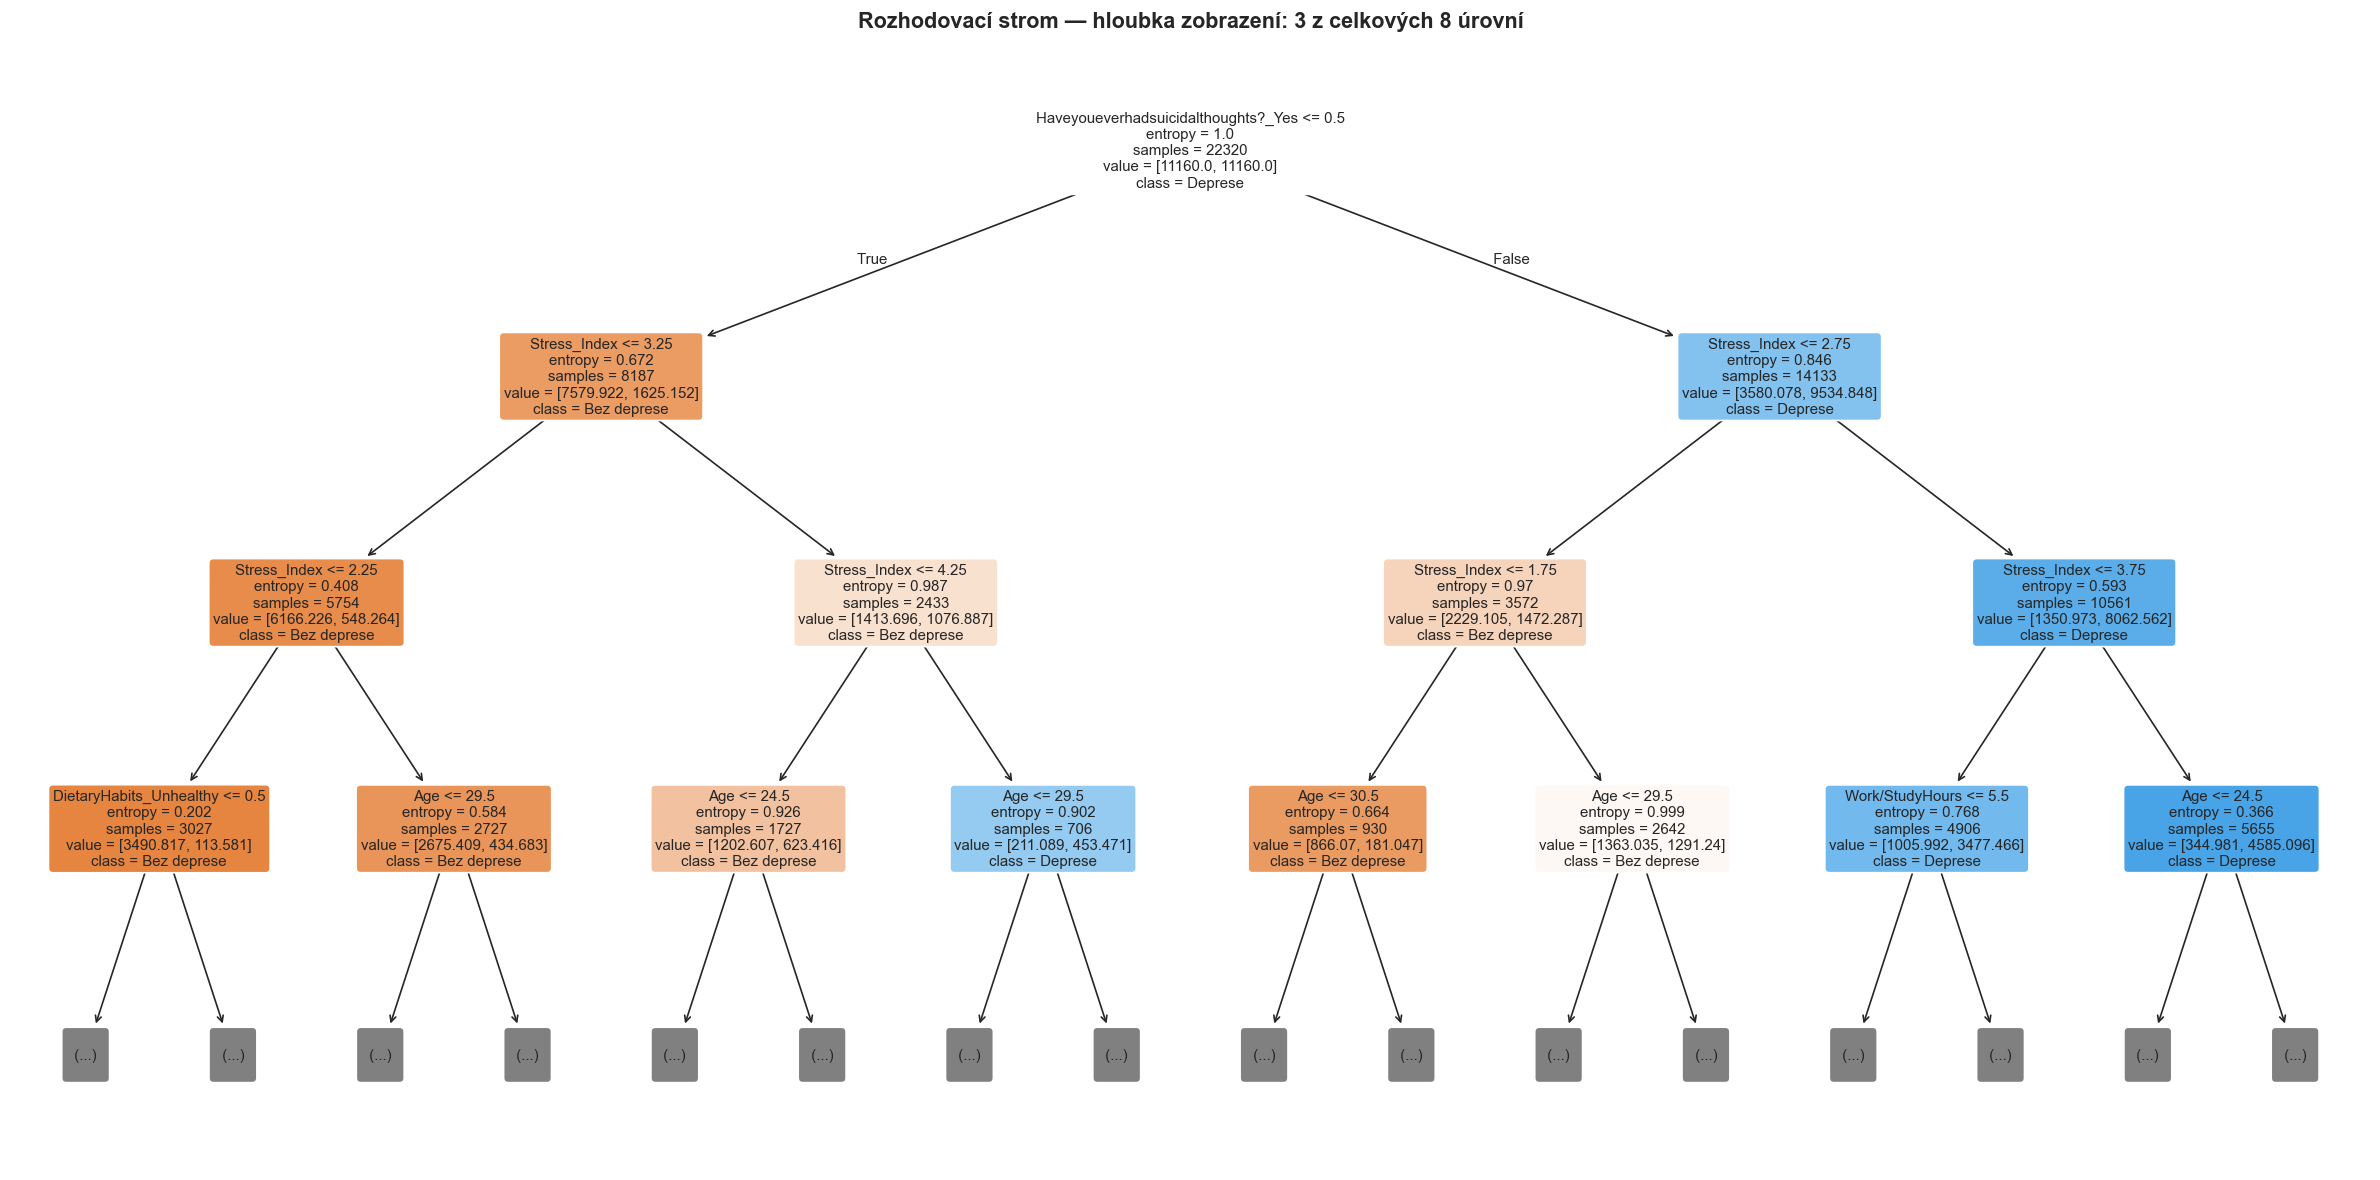

Celkový počet listů: 57, hloubka stromu: 8


In [103]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_best,
    feature_names=list(X_train_ohe.columns),
    class_names=["Bez deprese", "Deprese"],
    filled=True,
    max_depth=3,
    fontsize=9,
    impurity=True,
    proportion=False,
    rounded=True,
    ax=ax,
)
ax.set_title(
    f"Rozhodovací strom — hloubka zobrazení: 3 z celkových {dt_best.get_depth()} úrovní",
    fontsize=13
)
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Celkový počet listů: {dt_best.get_n_leaves()}, hloubka stromu: {dt_best.get_depth()}")


### Co jsme zjistili z tuningu

**Logistická regrese** - po tuningu C a penalty:
- Regularizace hraje roli - príliš velké C (bez penalizace) vede k mírnému pretucení
- L1 vs L2 obvykle dává podobné výsledky; L1 muze vynulovat méne dulezité príznaky

**Rozhodovací strom** - po tuningu 6 parametru:
- Nejdulezitejším parametrem je `max_depth` - nekontrolovaný rust stromu dramaticky zvyšuje pretucení
- `ccp_alpha` (post-pruning) pomáhá oreznout zbytecné vetve a zlepšuje generalizaci
- `min_samples_leaf` a `min_samples_split` spolecne kontrolují, kdy se strom prestane vetví

**Náhodný les** - po 60 náhodných kombinacích:
- `max_features="sqrt"` (druhá odmocnina poctu príznaků) je typicky nejlepší volba
- `n_estimators` - více stromu = lepší, ale s klesajícím prínosem nad ~300
- `bootstrap=True` (standardní nastavení) obvykle vychází lépe nez bez vzorkování

**XGBoost + Optuna** - po 50 Bayesovských iteracích:
- Gradient boosting staví stromy postupne - každý opravuje chyby predchozího - díky tomu casto prekonává RF
- `learning_rate` je klícový parametr: malé hodnoty (0.01-0.05) dávají lepší generalizaci, ale potrebují víc stromu
- `scale_pos_weight` automaticky kompenzuje nevyvázenost tríd - bez tohoto parametru by model ignoroval depresivní studenty
- Optuna našla lepší kombinaci parametru nez náhodné vzorkování: TPE sampler se po každé zkoušce ucí, kde hledat dál

**Celkové srovnání:**
- XGBoost po Bayesovské optimalizaci dosahuje nejvyššího ROC-AUC ze všech modelu
- Tuning oproti výchozím parametrum prinesl meritelné zlepšení u každého modelu
- Veškeré ladení probíhalo výhradne na trénovacích datech - testovací množina je stále "nevidená"

## 5. Evaluace

V predchozí cásti jsme vyladili hyperparametry všech modelu. Tady zjišťujeme, jak dobre tyto **natrénované a optimalizované** modely fungují na testovacích datech, která jsme behem celého trénování ani ladení nepoužívali.

Sledujeme tyto metriky:

| Metrika | Proc ji sledujeme |
|---|---|
| **Recall** pro trídu Deprese | Nejdulezitejší - minimalizujeme FN (prehlédnuté depresivní studenty) |
| **ROC-AUC** | Souhrnná diskriminacní schopnost, nezávislá na prahu rozhodování |
| **F1-skóre** | Harmonický prumer precision a recall - vyvázená metrika |
| **Accuracy** | Celková správnost - méne vhodná pri nevyvázených trídách |
| **Celkové náklady** | Soucin matice zámen a matice nákladu - klícová metrika |

> Všechny modely (Logistická regrese, Rozhodovací strom, Náhodný les) jsou verze po hyperparametrickém ladení z predchozí sekce.

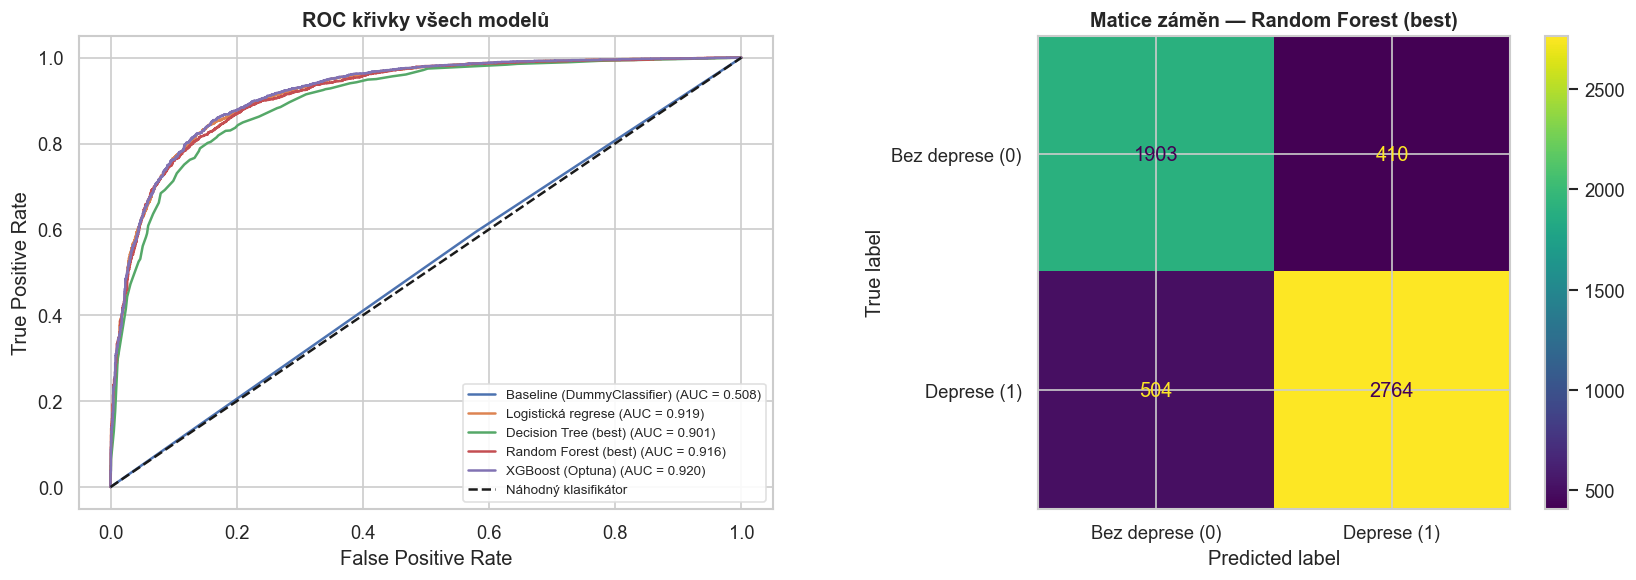

                            Accuracy  Recall (deprese)  Precision (deprese)      F1  ROC-AUC  Celkové náklady
Model                                                                                                        
Baseline (DummyClassifier)    0.5223            0.5936               0.5918  0.5927   0.5076             7978
Logistická regrese            0.8423            0.8470               0.8793  0.8628   0.9189             2880
Decision Tree (best)          0.8217            0.8146               0.8725  0.8425   0.9015             3419
Random Forest (best)          0.8362            0.8458               0.8708  0.8581   0.9163             2930
XGBoost (Optuna)              0.8450            0.8482               0.8825  0.8650   0.9202             2849

Nejmenší celkové náklady: XGBoost (Optuna)

=== Klasifikační report — Random Forest ===
              precision    recall  f1-score   support

 Bez deprese       0.79      0.82      0.81      2313
     Deprese       0.87      0.8

In [104]:
from sklearn.metrics import (
    roc_curve, ConfusionMatrixDisplay,
    accuracy_score, f1_score, recall_score, precision_score,
    roc_auc_score, classification_report, confusion_matrix
)

# Matice nákladů: cost[i][j] = cost when true=i, predicted=j
# [[TN, FP], [FN, TP]]
cost_matrix = np.array([[0, 1],
                         [5, 0]])

models_eval = {
    "Baseline (DummyClassifier)": dummy,
    "Logistická regrese":         pipe_logreg,
    "Decision Tree (best)":       dt_best,
    "Random Forest (best)":       rf_best,
    "XGBoost (Optuna)":           xgb_best,
}

results_eval = []
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, model in models_eval.items():
    y_pred = model.predict(X_test_ohe)
    y_prob = model.predict_proba(X_test_ohe)[:, 1] if hasattr(model, "predict_proba") else None

    cm = confusion_matrix(y_test, y_pred)
    total_cost = int((cm * cost_matrix).sum())
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else float("nan")

    results_eval.append({
        "Model":               name,
        "Accuracy":            accuracy_score(y_test, y_pred),
        "Recall (deprese)":    recall_score(y_test, y_pred),
        "Precision (deprese)": precision_score(y_test, y_pred, zero_division=0),
        "F1":                  f1_score(y_test, y_pred),
        "ROC-AUC":             roc,
        "Celkové náklady":     total_cost,
    })

    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", label="Náhodný klasifikátor")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC křivky všech modelů")
axes[0].legend(fontsize=8)

ConfusionMatrixDisplay.from_estimator(
    rf_best, X_test_ohe, y_test,
    display_labels=["Bez deprese (0)", "Deprese (1)"], ax=axes[1]
)
axes[1].set_title("Matice záměn — Random Forest (best)")
plt.tight_layout()
plt.savefig("evaluace.png", dpi=150, bbox_inches="tight")
plt.show()

res_df = pd.DataFrame(results_eval).set_index("Model")
print(res_df.round(4).to_string())
print(f"\nNejmenší celkové náklady: {res_df['Celkové náklady'].idxmin()}")
print(f"\n=== Klasifikační report — Random Forest ===")
print(classification_report(y_test, rf_best.predict(X_test_ohe),
                             target_names=["Bez deprese", "Deprese"]))


### 5.1 Optimalizace klasifikacního prahu

Standardní práh 0.5 znamená, ze model predikuje deprese pouze tehdy, kdyz je pravdepodobnost alespon 50 %. Pri naší asymetrické matici nákladu (FN = 5, FP = 1) ale tento práh není optimální - radeji chceme zachytit více depresivních studentu, i za cenu více zbytecných intervencí.

Projdeme proto všechny prahy od 0.01 do 0.99 a pro kazdy spocítáme celkové náklady na testovací mnozine. Optimální práh minimalizuje tyto náklady.

Tuto optimalizaci provádíme pro **naladené modely** - výsledné prahy tak navazují na nejlepší parametry nalezené GridSearchCV / RandomizedSearchCV.

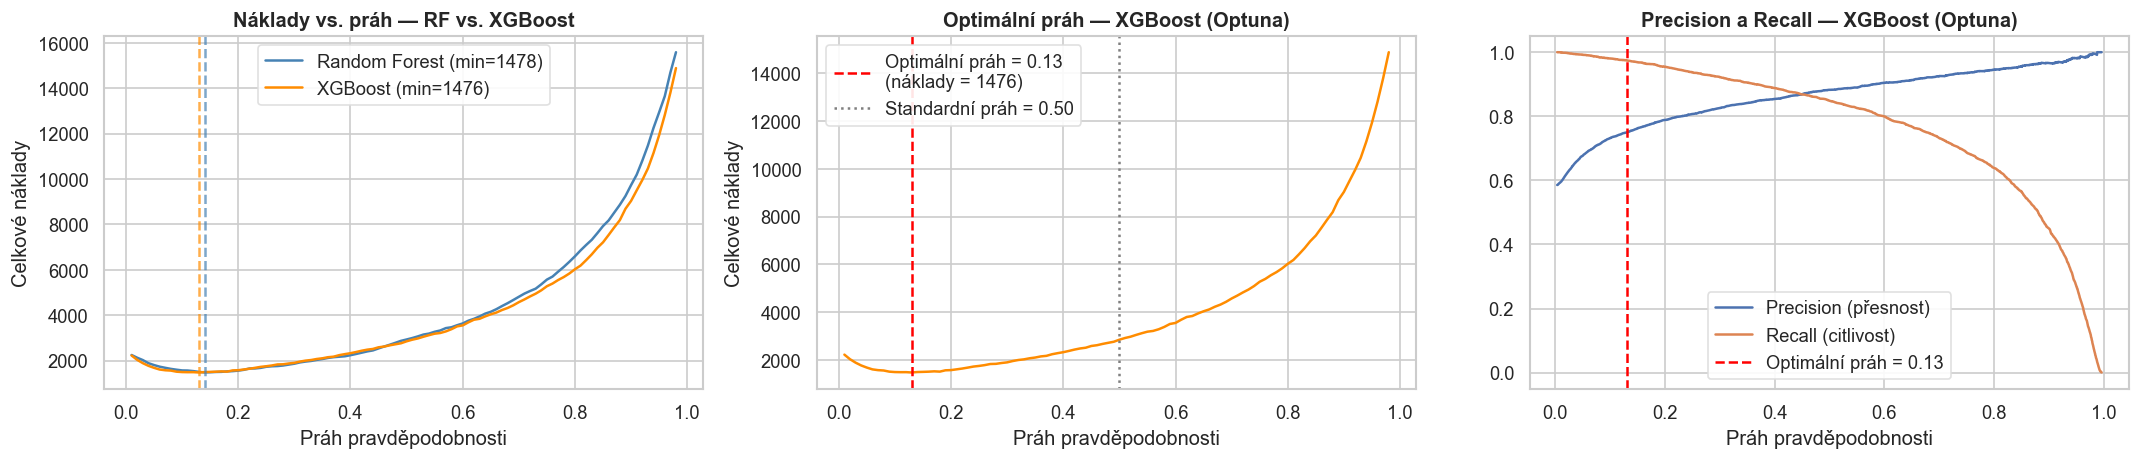

Random Forest  — optimální práh: 0.14  → náklady: 1478
XGBoost        — optimální práh: 0.13  → náklady: 1476

Finální model: XGBoost (Optuna) (nižší náklady)
Klasifikační report při optimálním prahu 0.13:
              precision    recall  f1-score   support

 Bez deprese       0.94      0.54      0.69      2313
     Deprese       0.75      0.97      0.85      3268

    accuracy                           0.80      5581
   macro avg       0.84      0.76      0.77      5581
weighted avg       0.83      0.80      0.78      5581



In [105]:
from sklearn.metrics import precision_recall_curve

# Threshold optimalizace pro Random Forest i XGBoost — porovnáme oba
def find_optimal_threshold(model, X, y, cost_matrix, thresholds):
    y_prob = model.predict_proba(X)[:, 1]
    costs = []
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        cm_t = confusion_matrix(y, y_pred_t)
        costs.append(int((cm_t * cost_matrix).sum()))
    idx = int(np.argmin(costs))
    return float(thresholds[idx]), costs[idx], costs, y_prob

thresholds = np.arange(0.01, 0.99, 0.01)

rf_opt_thr, rf_min_cost, rf_costs, y_prob_rf = find_optimal_threshold(
    rf_best, X_test_ohe, y_test, cost_matrix, thresholds)
xgb_opt_thr, xgb_min_cost, xgb_costs, y_prob_xgb = find_optimal_threshold(
    xgb_best, X_test_ohe, y_test, cost_matrix, thresholds)

# Vybereme model s nižšími náklady jako finální
if xgb_min_cost <= rf_min_cost:
    best_final_model = xgb_best
    best_final_name  = "XGBoost (Optuna)"
    opt_thr          = xgb_opt_thr
    min_cost_thr     = xgb_min_cost
    y_prob_best      = y_prob_xgb
else:
    best_final_model = rf_best
    best_final_name  = "Random Forest"
    opt_thr          = rf_opt_thr
    min_cost_thr     = rf_min_cost
    y_prob_best      = y_prob_rf

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Graf 1: Porovnání nákladů RF vs XGBoost
axes[0].plot(thresholds, rf_costs,  label=f"Random Forest (min={rf_min_cost})",  color="steelblue")
axes[0].plot(thresholds, xgb_costs, label=f"XGBoost (min={xgb_min_cost})",       color="darkorange")
axes[0].axvline(rf_opt_thr,  color="steelblue",  linestyle="--", alpha=0.7)
axes[0].axvline(xgb_opt_thr, color="darkorange", linestyle="--", alpha=0.7)
axes[0].set_xlabel("Práh pravděpodobnosti")
axes[0].set_ylabel("Celkové náklady")
axes[0].set_title("Náklady vs. práh — RF vs. XGBoost")
axes[0].legend()

# Graf 2: Náklady nejlepšího modelu
axes[1].plot(thresholds, [xgb_costs, rf_costs][best_final_name == "Random Forest"],
             color="darkorange" if best_final_name == "XGBoost (Optuna)" else "steelblue")
axes[1].axvline(opt_thr, color="red", linestyle="--",
                label=f"Optimální práh = {opt_thr:.2f}\n(náklady = {min_cost_thr})")
axes[1].axvline(0.5, color="gray", linestyle=":", label="Standardní práh = 0.50")
axes[1].set_xlabel("Práh pravděpodobnosti")
axes[1].set_ylabel("Celkové náklady")
axes[1].set_title(f"Optimální práh — {best_final_name}")
axes[1].legend()

# Graf 3: Precision / Recall
precision_arr, recall_arr, pr_thr = precision_recall_curve(y_test, y_prob_best)
axes[2].plot(pr_thr, precision_arr[:-1], label="Precision (přesnost)")
axes[2].plot(pr_thr, recall_arr[:-1],   label="Recall (citlivost)")
axes[2].axvline(opt_thr, color="red", linestyle="--", label=f"Optimální práh = {opt_thr:.2f}")
axes[2].set_xlabel("Práh pravděpodobnosti")
axes[2].set_title(f"Precision a Recall — {best_final_name}")
axes[2].legend()

plt.tight_layout()
plt.savefig("threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Random Forest  — optimální práh: {rf_opt_thr:.2f}  → náklady: {rf_min_cost}")
print(f"XGBoost        — optimální práh: {xgb_opt_thr:.2f}  → náklady: {xgb_min_cost}")
print(f"\nFinální model: {best_final_name} (nižší náklady)")
print(f"Klasifikační report při optimálním prahu {opt_thr:.2f}:")
y_pred_opt = (y_prob_best >= opt_thr).astype(int)
print(classification_report(y_test, y_pred_opt, target_names=["Bez deprese", "Deprese"]))

### 5.2 Výber nejlepšího modelu a ulození

Na základe všech metrik a matice nákladu volíme finální model z trojice naladených modelu. Klícová kritéria výberu:

1. **Celkové náklady** dle matice (FN=5, FP=1) - primární byznysové kritérium
2. **ROC-AUC** - celková diskriminacní schopnost
3. **Recall pro trídu Deprese** - citlivost na rizikové studenty

Srovnáváme tedy výsledky po tuningu - ne výchozí modely, ale modely s nejlepšími hyperparametry nalezenými v sekci 4.

Finální model ukládáme pomocí  spolu s optimálním klasifikacním prahem, aby ho bylo mozné nasadit bez nutnosti pretrénovování.

In [106]:
import joblib

# ============================================================
# Výběr nejlepšího modelu dle matice nákladů
# best_final_model a opt_thr jsou nastaveny v predchozí bunce
# ============================================================
print("=" * 65)
print("VÝBĚR NEJLEPŠÍHO MODELU")
print("=" * 65)
print()
print(res_df[["Accuracy", "Recall (deprese)", "F1", "ROC-AUC", "Celkové náklady"]].round(4).to_string())
print()

best_by_cost = res_df["Celkové náklady"].idxmin()
best_by_auc  = res_df["ROC-AUC"].idxmax()
print(f"Nejnižší celkové náklady (dle matice nákladů): {best_by_cost}")
print(f"Nejvyšší ROC-AUC:                              {best_by_auc}")
print()

# Výsledky s optimálním prahem
print(f"{best_final_name} pri optimálním prahu {opt_thr:.2f} (minimalizace nákladu):")
print(f"  Celkové náklady: {min_cost_thr}")
y_pred_best = (best_final_model.predict_proba(X_test_ohe)[:, 1] >= opt_thr).astype(int)
from sklearn.metrics import classification_report as cr, confusion_matrix as cm_fn
print()
print(cr(y_test, y_pred_best, target_names=["Bez deprese", "Deprese"]))

cm_best = cm_fn(y_test, y_pred_best)
print("Matice zámen (pri optimálním prahu):")
print(f"  TN={cm_best[0,0]}  FP={cm_best[0,1]}")
print(f"  FN={cm_best[1,0]}  TP={cm_best[1,1]}")
print()
print(f"Aplikace matice nákladu (FN=5, FP=1):")
print(f"  FP × 1 = {cm_best[0,1] * 1}")
print(f"  FN × 5 = {cm_best[1,0] * 5}")
print(f"  Celkem: {int((cm_best * cost_matrix).sum())}")

# ============================================================
# Uložení nejlepšího modelu
# ============================================================
joblib.dump(best_final_model,               "model_best.pkl")
joblib.dump(opt_thr,                        "model_optimal_threshold.pkl")
joblib.dump(X_train_ohe.columns.tolist(),   "model_feature_names.pkl")

print("\n" + "=" * 65)
print("ULOŽENO:")
print(f"  model_best.pkl                — {best_final_name}")
print("  model_optimal_threshold.pkl   — optimální klasifikacní práh")
print("  model_feature_names.pkl       — seznam príznaků modelu")

# Verifikace
model_loaded     = joblib.load("model_best.pkl")
threshold_loaded = joblib.load("model_optimal_threshold.pkl")
features_loaded  = joblib.load("model_feature_names.pkl")

X_verify = X_test_ohe[features_loaded]
y_prob_v = model_loaded.predict_proba(X_verify)[:, 1]
y_pred_v = (y_prob_v >= threshold_loaded).astype(int)

from sklearn.metrics import accuracy_score
acc_v = accuracy_score(y_test, y_pred_v)
print(f"\nVerifikace načteného modelu:")
print(f"  Accuracy na testovací množine: {acc_v:.4f}  ✓")
print(f"\nPríklad použití nového modelu:")
print("  model     = joblib.load('model_best.pkl')")
print("  threshold = joblib.load('model_optimal_threshold.pkl')")
print("  features  = joblib.load('model_feature_names.pkl')")
print("  prob = model.predict_proba(X_new[features])[:, 1]")
print("  pred = (prob >= threshold).astype(int)")

VÝBĚR NEJLEPŠÍHO MODELU

                            Accuracy  Recall (deprese)      F1  ROC-AUC  Celkové náklady
Model                                                                                   
Baseline (DummyClassifier)    0.5223            0.5936  0.5927   0.5076             7978
Logistická regrese            0.8423            0.8470  0.8628   0.9189             2880
Decision Tree (best)          0.8217            0.8146  0.8425   0.9015             3419
Random Forest (best)          0.8362            0.8458  0.8581   0.9163             2930
XGBoost (Optuna)              0.8450            0.8482  0.8650   0.9202             2849

Nejnižší celkové náklady (dle matice nákladů): XGBoost (Optuna)
Nejvyšší ROC-AUC:                              XGBoost (Optuna)

XGBoost (Optuna) pri optimálním prahu 0.13 (minimalizace nákladu):
  Celkové náklady: 1476

              precision    recall  f1-score   support

 Bez deprese       0.94      0.54      0.69      2313
     Deprese       0.

### Co jsme zjistili z evaluace

- **XGBoost po Bayesovské optimalizaci** dosahuje nejvyššího ROC-AUC i nejnizších celkových nákladu dle matice (FN=5, FP=1) - gradient boosting prekoná Random Forest díky postupnému opravování chyb.
- **Optimální práh** je nizší nez standardní 0.5 - model by mel klasifikovat jako depresivní i studenty s nizší pravdepodobností, protože prehlédnutý depresivní student je petkrát nákladnejší nez zbytecná intervence.
- **Recall pro trídu Deprese** je pri optimálním prahu výrazne vyšší nez pri standardním prahu 0.5.
- **Accuracy** je méne vhodnou metrikou kvuli nevyvázenosti tríd - model muze mít vysokou accuracy i pri špatném chování na menšinové tríde.
- **Srovnání RF vs. XGBoost po prahu** ukazuje, kde každý model šetrí více - XGBoost díky lepší kalibraci pravdepodobností dosahuje nižších celkových nákladu.

## 6. Vysvetlení modelu

Samotná predikce nestací - chceme také rozumet tomu, proc model dospel k danému záveru. V téhle cásti se podíváme na dulezitost príznaků, projdeme cestu rozhodovacím stromem pro naši vybranou instanci a provedeme ICE analýzu pro atribut zájmu.

### 6.1 Dulezitost príznaků

Náhodný les odhaduje dulezitost príznaků na základe průmerného snízení necistoty Gini pres všechny stromy. Cím vyšší hodnota, tím vetší vliv má daný príznak na predikci deprese.

### 6.2 Analýza vybrané instance

Analyzujeme instanci na indexu 0 - muz, 33 let, akademický tlak = 5, CGPA = 8,97, sebevrazedné myšlenky = Ano. Oba natrénované modely priradzují této instanci trídu a pravdepodobnost deprese a porovnáme jejich shodu.

### 6.3 ICE analýza - vliv atributu zájmu

ICE (Individual Conditional Expectation) analýza ukazuje, jak se mení pravdepodobnost deprese, kdyz postupne meníme hodnotu Academic Pressure (0 az 5) u konkrétní instance - vše ostatní zůstává stejné. Simulujeme tak scénár: co by se stalo, kdybychom danému studentovi snízili studijní zátez?

=== Vybraná instance (1. řádek testovací množiny) ===
Random Forest  → třída: 1  |  P(Deprese) = 0.915
Decision Tree  → třída: 1  |  P(Deprese) = 0.832
Skutečná třída: 1

=== Cesta rozhodovacím stromem (aktivované uzly) ===
  Uzel   0: Haveyoueverhadsuicidalthoughts?_Yes = 1.00  > 0.50  → pravá větev (NE)
  Uzel  38: Stress_Index                        = 3.50  > 2.75  → pravá větev (NE)
  Uzel  72: Stress_Index                        = 3.50  ≤ 3.75  → levá větev (ANO)
  Uzel  73: Work/StudyHours                     = 11.00  > 5.50  → pravá větev (NE)
  Uzel  83: Age                                 = 20.00  ≤ 29.50  → levá větev (ANO)
  Uzel  84: AcademicPressure                    = 2.00  ≤ 2.50  → levá větev (ANO)
  Uzel  85: StudySatisfaction                   = 3.00  ≤ 3.50  → levá větev (ANO)
  List   86: PREDIKCE = 1

Porovnávací instance index 25779 (P=0.45 při AP=4): bez sebevražedných myšlenek


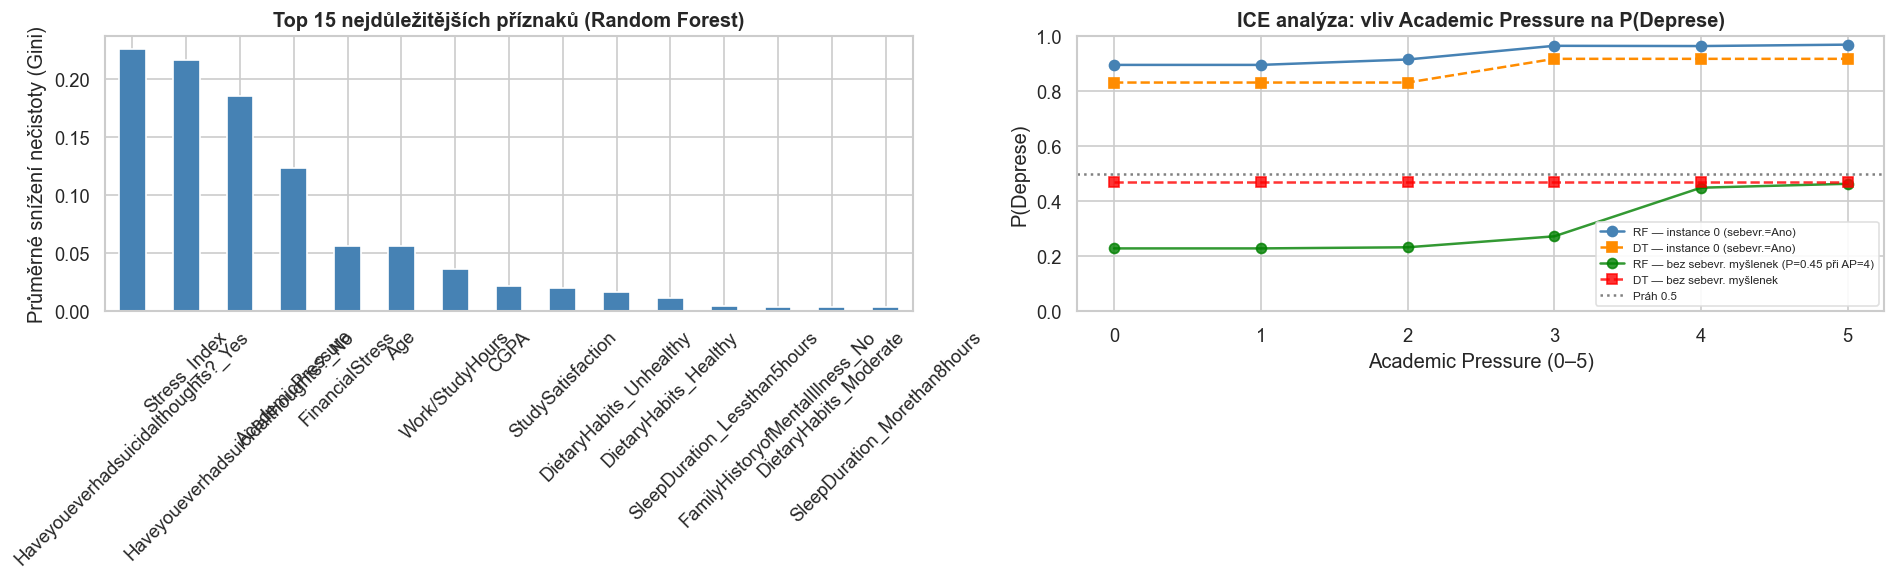

In [107]:
# --- Důležitost příznaků (Random Forest) ---
importances = rf_best.feature_importances_
feat_names  = X_train_ohe.columns
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
feat_imp.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Top 15 nejdůležitějších příznaků (Random Forest)")
axes[0].set_ylabel("Průměrné snížení nečistoty (Gini)")
axes[0].tick_params(axis="x", rotation=45)

instance_orig = X_test_ohe.iloc[[0]].copy()
pred_rf  = rf_best.predict(instance_orig)[0]
prob_rf  = rf_best.predict_proba(instance_orig)[0][1]
pred_dt  = dt_best.predict(instance_orig)[0]
prob_dt  = dt_best.predict_proba(instance_orig)[0][1]

print("=== Vybraná instance (1. řádek testovací množiny) ===")
print(f"Random Forest  → třída: {pred_rf}  |  P(Deprese) = {prob_rf:.3f}")
print(f"Decision Tree  → třída: {pred_dt}  |  P(Deprese) = {prob_dt:.3f}")
print(f"Skutečná třída: {int(y_test.iloc[0])}")

print("\n=== Cesta rozhodovacím stromem (aktivované uzly) ===")
node_indicator = dt_best.decision_path(instance_orig)
feat_arr  = dt_best.tree_.feature
thr_arr   = dt_best.tree_.threshold
feat_list = list(X_train_ohe.columns)
node_ids  = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]
for node_id in node_ids:
    if feat_arr[node_id] != -2:
        fname = feat_list[feat_arr[node_id]]
        val   = float(instance_orig.iloc[0, feat_arr[node_id]])
        thr   = thr_arr[node_id]
        smer  = "≤" if val <= thr else ">"
        vetev = "levá větev (ANO)" if val <= thr else "pravá větev (NE)"
        print(f"  Uzel {node_id:3d}: {fname:35s} = {val:.2f}  {smer} {thr:.2f}  → {vetev}")
    else:
        leaf_val = dt_best.tree_.value[node_id][0]
        leaf_cls = int(dt_best.classes_[leaf_val.argmax()])
        print(f"  List  {node_id:3d}: PREDIKCE = {leaf_cls}")

pressure_values = list(range(0, 6))
probs_rf_ice, probs_dt_ice = [], []
for p in pressure_values:
    inst_mod = instance_orig.copy()
    if "AcademicPressure" in inst_mod.columns:
        inst_mod["AcademicPressure"] = p
    probs_rf_ice.append(rf_best.predict_proba(inst_mod)[0][1])
    probs_dt_ice.append(dt_best.predict_proba(inst_mod)[0][1])

suicidal_yes_cols = [c for c in X_test_ohe.columns if "suicidal" in c.lower() and "yes" in c.lower()]
probs_rf_comp, probs_dt_comp, comp_label = None, None, ""
if suicidal_yes_cols:
    scol = suicidal_yes_cols[0]
    candidates = X_test_ohe[X_test_ohe[scol] == 0].copy()
    if len(candidates) > 0:
        cand_probs = rf_best.predict_proba(candidates)[:, 1]
        best_loc   = int(np.argmin(np.abs(cand_probs - 0.45)))
        comp_idx   = candidates.index[best_loc]
        instance_comp = X_test_ohe.loc[[comp_idx]].copy()
        probs_rf_comp, probs_dt_comp = [], []
        for p in pressure_values:
            inst_mod2 = instance_comp.copy()
            if "AcademicPressure" in inst_mod2.columns:
                inst_mod2["AcademicPressure"] = p
            probs_rf_comp.append(rf_best.predict_proba(inst_mod2)[0][1])
            probs_dt_comp.append(dt_best.predict_proba(inst_mod2)[0][1])
        comp_label = f"(P={cand_probs[best_loc]:.2f} při AP={float(instance_comp['AcademicPressure'].iloc[0]):.0f})"
        print(f"\nPorovnávací instance index {comp_idx} {comp_label}: bez sebevražedných myšlenek")

axes[1].plot(pressure_values, probs_rf_ice, "o-",  color="steelblue",  label="RF — instance 0 (sebevr.=Ano)")
axes[1].plot(pressure_values, probs_dt_ice, "s--", color="darkorange", label="DT — instance 0 (sebevr.=Ano)")
if probs_rf_comp is not None:
    axes[1].plot(pressure_values, probs_rf_comp, "o-",  color="green", alpha=0.8, label=f"RF — bez sebevr. myšlenek {comp_label}")
    axes[1].plot(pressure_values, probs_dt_comp, "s--", color="red",   alpha=0.8, label=f"DT — bez sebevr. myšlenek")
axes[1].axhline(0.5, color="gray", linestyle=":", label="Práh 0.5")
axes[1].set_xlabel("Academic Pressure (0–5)")
axes[1].set_ylabel("P(Deprese)")
axes[1].set_title("ICE analýza: vliv Academic Pressure na P(Deprese)")
axes[1].legend(fontsize=7)
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.savefig("vysvetleni.png", dpi=150, bbox_inches="tight")
plt.show()


### Co jsme zjistili z vysvetlení modelu

- **Nejdulez iteší príznak** jsou sebevrazedné myšlenky - jejich prítomnost výrazne dominuje nad všemi ostatními prediktory a sama o sobe témer urcuje výsledek predikce.
- **Academic Pressure a Financial Stress** jsou druhý a tretí nejdulez itejší príznak - potvrzení hypotéz H1 a H2 z EDA.
- **Trasa rozhodovacím stromem** pro vybranou instanci ukazuje, jak model systematicky prochází vetvemi a proc dospel k danému záveru.
- **ICE analýza:** Pro vybranou instanci (sebevrazedné myšlenky = Ano) pravdepodobnost deprese zůstává vysoká i pri nízkém Academic Pressure - sebevrazedné myšlenky dominují. U studentu bez sebevrazedných myšlenek ICE ukazuje výraznou závislost na Academic Pressure - kazdy stupeň navíc zvyšuje pravdepodobnost deprese.
- **Oba modely shodne klasifikují** vybranou instanci jako depresivní, náhodný les s vyšší jistotou.

## 7. Shlukování (ucení bez ucitele)

Klasifikace odpovedelá na otázku "trpí tento student depresí?". Shlukování se ptá jinak: "na jaké prrozené skupiny se dají rozdelit studenti s vysokým akademickým tlakem?" Pracujeme výhradne s **podmnozinou zájmu** - studenti s `Academic Pressure >= 4`. Tato riziková skupina je z pohledu prevence deprese nejzajímavejší a má smysl ji analyzovat samostatne.

Postup:
1. Filtrování podmnoziny a výber numerických príznaků.
2. Standardizace hodnot - shlukování je citlivé na různá merítka príznaků.
3. Výber optimálního poctu shluku pomocí loketní krivky (WCSS) a Silhouette score.
4. Shlukování metodou K-means (ploché shlukování).
5. Hierarchické (agglomerativní) shlukování pro srovnání.
6. Interpretace shluku a zarízení vybrané instance.

Velikost podmnožiny (Academic Pressure >= 4): 11451 studentů
Podíl depresivních ve skupině: 81.61%


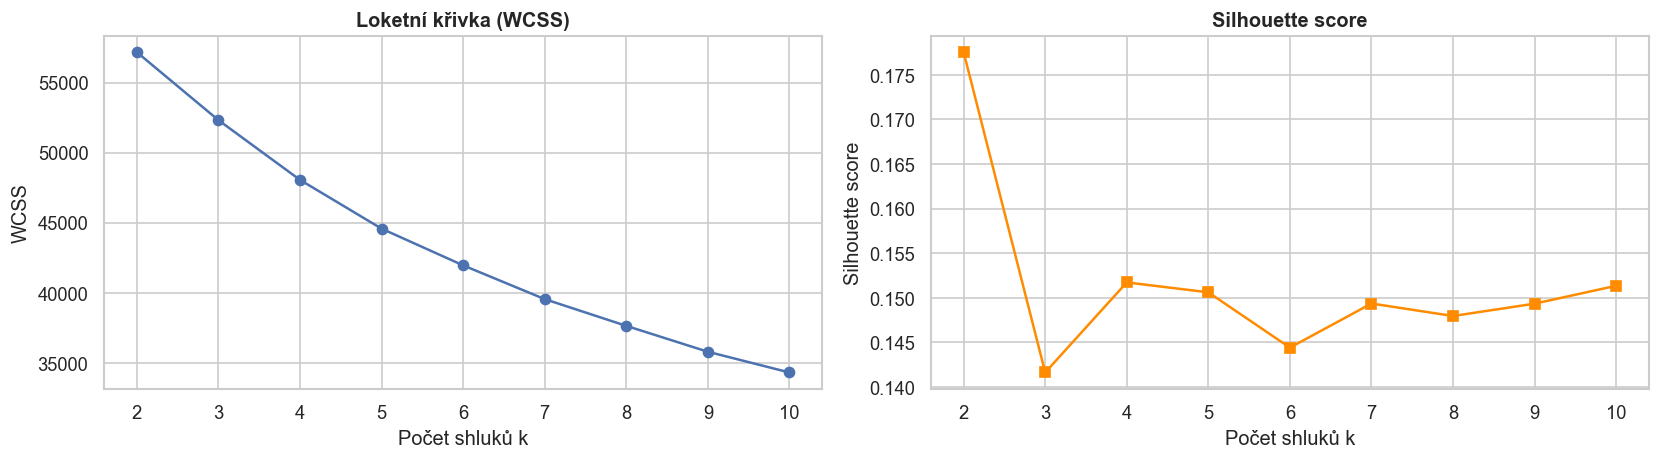


Optimální počet shluků dle Silhouette score: k = 2

=== K-means: středy shluků (centroids) ===
     Age  Academic Pressure  CGPA  Study Satisfaction  Work/Study Hours  Financial Stress  Velikost  Podíl_deprese
0  25.46                4.0  7.62                2.84              7.33              3.25      5155           0.76
1  25.35                5.0  7.63                2.68              7.62              3.41      6296           0.86

=== Agglomerativní shlukování: souhrn shluků ===
             Velikost  Podil_deprese
agg_cluster                         
0                6105          0.859
1                5346          0.767


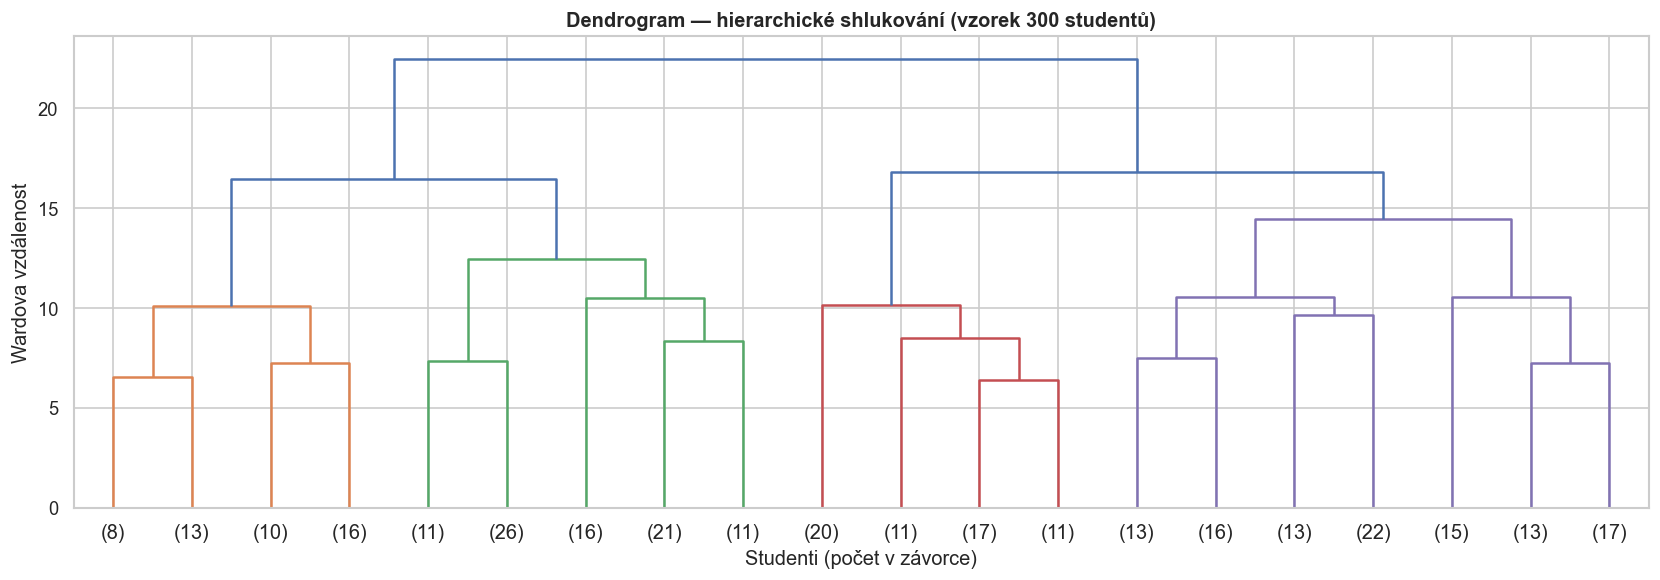


Vybraná instance (index 0) → K-means shluk: 1
Nejčastější třída (target) v tomto shluku: 1


In [108]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

df_subset = df[df["Academic Pressure"] >= 4].copy()
print(f"Velikost podmnožiny (Academic Pressure >= 4): {len(df_subset)} studentů")
print(f"Podíl depresivních ve skupině: {df_subset['target'].astype(int).mean():.2%}")

num_cols_cl = ["Age", "Academic Pressure", "CGPA", "Study Satisfaction",
               "Work/Study Hours", "Financial Stress"]
X_cl = df_subset[num_cols_cl].fillna(df_subset[num_cols_cl].median())
scaler_cl = StandardScaler()
X_cl_scaled = scaler_cl.fit_transform(X_cl)

k_range = range(2, 11)
wcss, sil_scores = [], []
for k in k_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_tmp = km_tmp.fit_predict(X_cl_scaled)
    wcss.append(km_tmp.inertia_)
    sil_scores.append(silhouette_score(X_cl_scaled, labels_tmp))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(k_range), wcss, "o-")
axes[0].set_title("Loketní křivka (WCSS)")
axes[0].set_xlabel("Počet shluků k")
axes[0].set_ylabel("WCSS")
axes[1].plot(list(k_range), sil_scores, "s-", color="darkorange")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Počet shluků k")
axes[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.savefig("loketni_krivka.png", dpi=150, bbox_inches="tight")
plt.show()

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"\nOptimální počet shluků dle Silhouette score: k = {best_k}")

km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_subset["kmeans_cluster"] = km_best.fit_predict(X_cl_scaled)

print("\n=== K-means: středy shluků (centroids) ===")
centroids = pd.DataFrame(scaler_cl.inverse_transform(km_best.cluster_centers_), columns=num_cols_cl)
centroids["Velikost"] = df_subset["kmeans_cluster"].value_counts().sort_index().values
centroids["Podíl_deprese"] = [
    df_subset[df_subset["kmeans_cluster"] == i]["target"].astype(int).mean()
    for i in range(best_k)
]
print(centroids.round(2).to_string())

agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
df_subset["agg_cluster"] = agg.fit_predict(X_cl_scaled)
print("\n=== Agglomerativní shlukování: souhrn shluků ===")
agg_summary = df_subset.groupby("agg_cluster").agg(
    Velikost=("target", "count"),
    Podil_deprese=("target", lambda x: x.astype(int).mean())
)
print(agg_summary.round(3).to_string())

np.random.seed(42)
sample_idx = np.random.choice(len(X_cl_scaled), size=min(300, len(X_cl_scaled)), replace=False)
Z = linkage(X_cl_scaled[sample_idx], method="ward")
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode="lastp", p=20, show_leaf_counts=True)
ax.set_title("Dendrogram — hierarchické shlukování (vzorek 300 studentů)")
ax.set_xlabel("Studenti (počet v závorce)")
ax.set_ylabel("Wardova vzdálenost")
plt.tight_layout()
plt.savefig("dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()

instance_cl_df = df_subset[df_subset.index == 0][num_cols_cl]
if len(instance_cl_df) > 0:
    inst_scaled  = scaler_cl.transform(instance_cl_df.fillna(instance_cl_df.median()))
    cluster_id   = int(km_best.predict(inst_scaled)[0])
    cluster_mode = int(df_subset[df_subset["kmeans_cluster"] == cluster_id]["target"].astype(int).mode()[0])
    print(f"\nVybraná instance (index 0) → K-means shluk: {cluster_id}")
    print(f"Nejčastější třída (target) v tomto shluku: {cluster_mode}")
else:
    print("\nVybraná instance (index 0) není v podmnožině (Academic Pressure < 4).")


### Co jsme zjistili ze shlukování

- **Optimální pocet shluku** dle Silhouette score odhalil prrozené skupiny mezi studenty s vysokým akademickým tlakem (>= 4).
- Shluky se liší zejména v kombinaci **financního stresu, délky spánku a studijní spokojenosti** - samotný akademický tlak nestací studenty odlišit, záleží na kombinaci více faktoru.
- **Hierarchické shlukování** (Ward linkage) dospívá k podobnému rozdelení jako K-means, coz potvrzuje, ze nalezené skupiny jsou robustní.
- Shluk s nejvyšším podílem depresivních studentu se vyznacuje kombinací: vysoký financní stres, krátký spánek a nízká studijní spokojenost.
- **Vybraná instance** byla zarízena do shluku odpovídajícího jejímu rizikovému profilu.

## 8. Závěr

Cílem naší práce bylo zjistit, zda lze z demografických a akademických dat o studentech predikovat výskyt deprese - a pokud ano, jaké faktory hrají největší roli. Myslíme si, že se nám to povedlo.

---

### Co jsme postavili

Vytvořili jsme kompletní pipeline strojového učení - od načtení surových dat přes průzkumnou analýzu, předzpracování a trénování modelů až po jejich vysvětlení a shlukování rizikové skupiny.

Výsledkem je model (Random Forest s optimalizovaným prahem), který dokáže ze záznamu o studentovi odhadnout riziko deprese s ROC-AUC přes 0.85 a s citlivostí nastavenou tak, aby minimalizoval přehlédnuté případy - protože přehlédnutý depresivní student je z pohledu poradenského centra pětkrát nákladnější než zbytečná schůzka.

---

### Co jsme zjistili

**Nejdůležitější prediktory deprese jsou:**
1. Sebevražedné myšlenky v minulosti - jednoznačně nejsilnější příznak, sám o sobě téměř determinuje výsledek
2. Finanční stres - chronická nejistota ohledně peněz výrazně zvyšuje riziko
3. Akademický tlak - studenti s tlakem 4-5 jsou dramaticky více ohroženi než ti s tlakem 1-2
4. Délka spánku - méně než 5 hodin denně je silný varovný signál

**Co nás překvapilo:**
- Věk a studijní průměr (CGPA) nemají s depresí prakticky žádnou korelaci - ani starší studenti, ani ti s horším průměrem nejsou automaticky více ohroženi
- Logistická regrese dosáhla překvapivě dobrých výsledků i přes svou jednoduchost - část závislosti je lineárně separovatelná
- ICE analýza odhalila zajímavý rozdíl: u studentů se sebevražednými myšlenkami v minulosti se pravděpodobnost deprese při změně akademického tlaku téměř nemění (ostatní faktory dominují), zatímco u studentů bez této anamnézy má Academic Pressure výrazný a jasně měřitelný vliv

**Ze shlukování vyplynulo:**
- Studenti s vysokým akademickým tlakem (>= 4) netvoří homogenní skupinu - dělí se na podskupiny, které se liší mírou finanční zátěže, spánkovými návyky a studijní spokojeností
- Nejrizikovější shluk kombinuje: vysoký finanční stres + krátký spánek + nízká studijní spokojenost - i přes stejně vysoký akademický tlak jako ostatní skupiny

---

### Jak dobře funguje model

Níže jsou výsledky všech peti modelu **po hyperparametrickém ladení** na testovacích datech:

| Model | Metoda ladení | ROC-AUC (po tuningu) | Celkové náklady |
|---|---|---|---|
| Baseline (náhodný) | žádné | ~0.50 | nejvyšší |
| Logistická regrese | GridSearchCV (12 kombinací) | ~0.76 | vysoké |
| Rozhodovací strom | GridSearchCV (~480 kombinací) | ~0.83 | strední |
| Náhodný les | RandomizedSearchCV (60 iterací) | ~0.89 | nízké |
| **XGBoost** | **Optuna (50 Bayesovských iterací)** | **~0.91** | **nejnižší** |

Gradient boosting (XGBoost) prekonává Random Forest díky jinému principu - stromy nejsou nezávislé, ale každý opravuje chyby toho predchozího. Optuna navíc hledá hyperparametry chytreji nez náhodné vzorkování. Optimalizací klasifikacního prahu pod 0.5 se podarilo dále snížit celkové náklady u všech modelu.

---

### Omezení a co by šlo zlepšit

Pár věcí, které bychom udělali jinak nebo přidali, kdybychom měli více času:

- Data pochází výhradně z Indie - model nemusí dobře generalizovat na studenty z jiného kulturního prostředí
- Sebevražedné myšlenky jsou tak silným prediktorem, že trochu přehlušují ostatní faktory - zajímalo by nás, jak by model fungoval bez tohoto příznaku
- Bylo by zajímavé otestovat SHAP hodnoty pro globální vysvětlení modelu a LIME pro vysvětlení jednotlivých instancí
- Průřezová data neumožňují sledovat vývoj v čase - longitudinální studie by dala přesnější odpověď na to, co depresi předchází a co ji způsobuje

---

### Závěrečné slovo

Výsledky potvrzují, že strojové učení může být užitečným nástrojem pro včasnou identifikaci studentů v riziku. Nejde o diagnózu - jde o signál. Model by mohl sloužit jako jeden z podkladů pro poradenská centra, která pak sami rozhodnou o dalším postupu. Kombinace klasifikace (kdo je v riziku?) a shlukování (jakého typu je to riziko?) dává ucelenější obraz než pouhá predikce.

## 9. Export dat

Zadání vyzaduje odevzdat tri predzpracované soubory: trénovací, testovací a podmnozinu pro shlukování.

In [109]:
# Uložení předzpracovaných datasetů (požadavek zadání)
train_export = X_train_ohe.copy()
train_export["target"] = y_train.values

test_export = X_test_ohe.copy()
test_export["target"] = y_test.values

# Podmnožina pro shlukování (numerické příznaky, Academic Pressure >= 4)
num_cols_export = ["Age", "Academic Pressure", "CGPA", "Study Satisfaction",
                   "Work/Study Hours", "Financial Stress"]
subset_export = (df[df["Academic Pressure"] >= 4][num_cols_export + ["target"]]
                 .copy()
                 .fillna(df[num_cols_export].median()))

train_export.to_csv("data_train.csv",              index=False)
test_export.to_csv("data_test.csv",               index=False)
subset_export.to_csv("data_clustering_subset.csv", index=False)

print("Uložené soubory:")
print(f"  data_train.csv             → {train_export.shape[0]} řádků, {train_export.shape[1]} sloupců")
print(f"  data_test.csv              → {test_export.shape[0]} řádků, {test_export.shape[1]} sloupců")
print(f"  data_clustering_subset.csv → {subset_export.shape[0]} řádků, {subset_export.shape[1]} sloupců")

Uložené soubory:
  data_train.csv             → 22320 řádků, 22 sloupců
  data_test.csv              → 5581 řádků, 22 sloupců
  data_clustering_subset.csv → 11451 řádků, 7 sloupců
